In [1]:
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import datetime
from scipy.interpolate import griddata
from mpl_toolkits.basemap import Basemap
import os
from sklearn.linear_model import LinearRegression


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
start_time_era5 = datetime.datetime(1900, 1, 1, 0, 0, 0)

# Границы региона, загружаем только эти данные из хранилища
lon_min_era5, lon_max_era5, lat_min_era5, lat_max_era5 = 50, 110, 70, 83

In [3]:
# Создаем координатную сетку на основе одного из файлов. Сетка не меняется между файлами
lat1, lat2 = (90-lat_max_era5)*4, (90-lat_min_era5)*4+1
lon1, lon2 = lon_min_era5*4, lon_max_era5*4+1

file = '/mnt/hippocamp/DATA/ERA5/w10/era5_uv10m_2020-09.nc'
data = Dataset(file, 'r')

longitude = np.array(data.variables['longitude'][lon1:lon2])
latitude = np.array(data.variables['latitude'][lat1:lat2])
lon_grid, lat_grid = np.meshgrid(longitude, latitude)

In [4]:
def get_wind(year, month, borders):
    file = f'/mnt/hippocamp/DATA/ERA5/w10/era5_uv10m_{year}-{month:02}.nc'
    data = Dataset(file, 'r')

    u10 = np.asarray(data.variables['u10'][:,lat1:lat2,lon1:lon2])
    v10 = np.asarray(data.variables['v10'][:,lat1:lat2,lon1:lon2])

    u10_upd = u10[:,(lat_max_era5-borders[0])*4:(lat_max_era5-borders[1])*4+1,
                  (borders[3]-lon_min_era5)*4:(borders[2]-lon_max_era5)*4]
    v10_upd = v10[:,(lat_max_era5-borders[0])*4:(lat_max_era5-borders[1])*4+1,
                  (borders[3]-lon_min_era5)*4:(borders[2]-lon_max_era5)*4]
    
    list_u10 = np.split(u10, u10.shape[0]/24, axis=0)
    array_u10 = np.array([np.mean(a, axis=0) for a in list_u10])

    list_v10 = np.split(v10, v10.shape[0]/24, axis=0)
    array_v10 = np.array([np.mean(a, axis=0) for a in list_v10])
    
    list_u10_upd = np.split(u10_upd, u10_upd.shape[0]/24, axis=0)
    array_u10_upd = np.array([np.mean(a, axis=0) for a in list_u10_upd])

    list_v10_upd = np.split(v10_upd, v10_upd.shape[0]/24, axis=0)
    array_v10_upd = np.array([np.mean(a, axis=0) for a in list_v10_upd])

    start_date = datetime.datetime(year, month, 1)
    finish_date = (start_date + datetime.timedelta(days=len(list_v10_upd)))
    dates = [(start_date + datetime.timedelta(days=i)).date() for i in range((finish_date - start_date).days)]
    data.close()

    return array_u10, array_v10, array_u10_upd, array_v10_upd, dates

In [5]:
def draw_border_wind(dates, NB_75E, NB_delta_75E, dates_wind, wind_data, Ekman_data, title):
    x1 = dates
    y1 = NB_75E
    y3 = NB_delta_75E

    y5 = wind_data
    y6 = Ekman_data

    fig, ax1 = plt.subplots(dpi=300)
    ax2 = ax1.twinx()

    # ax3 = ax1.twinx()
    # ax3.spines["right"].set_position(("outward", 60))
    # ax3.spines["right"].set_visible(True)

    ax4 = ax1.twinx()
    ax4.spines["right"].set_position(("outward", 60))
    ax4.spines["right"].set_visible(True)

    line1, = ax1.plot(x1, y1, label='75E', linestyle='--', color='red', linewidth=0.5)

    line3, = ax2.plot(x1, y3, label='delta75E', linestyle='-', color='red', linewidth=1)

    line6, = ax4.plot(x1, y6, label='Ekman', linestyle='-', color='black', linewidth=1)

    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)

    all3 = np.array(y3)
    all_wind = np.array(y5)
    all6 = np.array(y6)

    a1, a2, a3, b1, b2, b3 = (np.nanmax(all3), all_wind.max(), np.nanmax(all6),
                              np.nanmin(all3), all_wind.min(), np.nanmin(all6))

    if abs(a1/b1) > abs(a2/b2):
        new_a2 = a1 * b2 / b1
        new_b2 = b2

        new_a3 = a1 * b3 / b1
        new_b3 = b3

    elif abs(a1/b1) < abs(a2/b2):
        new_a2 = a2
        new_b2 = b1 * a2 / a1

        new_a3 = a3
        new_b3 = b1 * a3 / a1
        
    ax2.set_ylim(b1 + 0.05 * b1, a1 + 0.05 * a1)
    # ax3.set_ylim(new_b2 + 0.05 * new_b2, new_a2 + 0.05 * new_a2)
    ax4.set_ylim(new_b3 + 0.05 * new_b3, new_a3 + 0.05 * new_a3)

    # lines = [line1, line2, line3, line4, line5, line6]
    # labels = [line.get_label() for line in lines]
    # ax1.legend(lines, labels, loc='upper left')

    ax1.set_ylabel('Northern border')
    ax2.set_ylabel('Northern border change, km')
    
    ax4.set_ylabel('Ekman drift, km')

    step = len(x1) // 15 + 1
    selected_indices = range(0, len(x1), step)

    selected_x = [x1[i] for i in selected_indices]
    ax1.set_xticks(selected_x)
    ax1.set_xticklabels([date.strftime('%Y-%m-%d') for date in selected_x], rotation=45)

    plt.title(title)
    plt.grid(axis='y', which='both')
    plt.savefig(f'border_pictures_Kara/N{title}', dpi=300, bbox_inches='tight')

In [6]:
def make_wind(borders, months, year, start_date, finish_date, lat1=lat1, lat2=lat2, lon1=lon1, lon2=lon2):
    array_u10, array_v10 = np.empty((0, lat2-lat1, lon2-lon1)), np.empty((0, lat2-lat1, lon2-lon1))

    array_u10_upd = np.empty((0, (borders[0]-borders[1])*4+1, (borders[2]-borders[3])*4+1))
    array_v10_upd = np.empty((0, (borders[0]-borders[1])*4+1, (borders[2]-borders[3])*4+1))
    dates_era = []

    for month in months:
        array_u10_, array_v10_, array_u10_upd_, array_v10_upd_, dates_era_ = get_wind(year=year, month=month, borders=borders)
        array_u10 = np.concatenate((array_u10, array_u10_))
        array_v10 = np.concatenate((array_v10, array_v10_))
        array_u10_upd = np.concatenate((array_u10_upd, array_u10_upd_))
        array_v10_upd = np.concatenate((array_v10_upd, array_v10_upd_))
        dates_era += dates_era_

    print(array_u10.shape, array_v10.shape, array_u10_upd.shape, array_v10_upd.shape, len(dates_era))

    start_date -= datetime.timedelta(days=1)
    finish_date += datetime.timedelta(days=1)

    date_mask = [(start_date <= d <= finish_date) for d in dates_era]
    dates_wind = [d for d, keep in zip(dates_era, date_mask) if keep]
    array_u10_filtered = array_u10[date_mask,:,:]
    array_v10_filtered = array_v10[date_mask,:,:]
    array_u10_upd_filtered = array_u10_upd[date_mask,:,:]
    array_v10_upd_filtered = array_v10_upd[date_mask,:,:]

    print(array_u10_filtered.shape, array_v10_filtered.shape,
        array_u10_upd_filtered.shape, array_v10_upd_filtered.shape,
        len(dates_wind))
    
    return dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered

In [7]:
def get_regression(U_neg, V, border):
    X1 = np.array(U_neg)
    X2 = np.array(V)
    y = np.array(border)

    mask = ~np.isnan(y)
    X = np.column_stack((X1, X2))
    X_clean = X[mask]
    y_clean = y[mask]

    model = LinearRegression()
    model.fit(X_clean, y_clean)

    y_pred = model.predict(X_clean)
    
    return y_pred, model.coef_, model.intercept_

In [8]:
def mean_wind(array_u10_upd_filtered, array_v10_upd_filtered):
    u10_mean_neg = [-np.mean(array_u10_upd_filtered[i]) for i in range(array_u10_upd_filtered.shape[0])]
    v10_mean = [np.mean(array_v10_upd_filtered[i]) for i in range(array_v10_upd_filtered.shape[0])]
    wind_mean = [(a**2 + b**2)**0.5 for a, b in zip(u10_mean_neg, v10_mean)]
    U_neg = [a * b for a, b in zip(wind_mean, u10_mean_neg)]
    V = [a * b for a, b in zip(wind_mean, v10_mean)]

    return u10_mean_neg, v10_mean, wind_mean, U_neg, V

In [9]:
def make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V):
    rho_air = 1.225
    rho_water = 1025
    f = 1.41 * 0.0001
    C = 1.3 * 0.001
    H = 10

    NB_delta_75E_km = [b * 111.3 if not np.isnan(b) else np.nan for b in NB_delta_75E]
    NB_delta_80E_km = [b * 111.3 if not np.isnan(b) else np.nan for b in NB_delta_80E]
    U_Ekman = [u * ((rho_air * C) / (rho_water * f) / H) for u in U_neg]
    U_Ekman_sm = [u * 100 for u in U_Ekman]
    V_Ekman = [v * ((rho_air * C) / (rho_water * f) / H) for v in V]
    V_Ekman_sm = [v * 100 for v in V_Ekman]

    U_Ekman_sum = [np.sum(U_Ekman[i:i+3]) for i in range(0, len(U_Ekman), 3) if len(U_Ekman[i:i+3]) == 3]
    V_Ekman_sum = [np.sum(V_Ekman[i:i+3]) for i in range(0, len(V_Ekman), 3) if len(V_Ekman[i:i+3]) == 3]
    Ekman_data_u = [60 * 60 * 24 / 1000 * u for u in U_Ekman_sum]
    Ekman_data_v = [60 * 60 * 24 / 1000 * v for v in V_Ekman_sum]

    return NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v

In [10]:
def wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km):
    U_neg_averages = [np.mean(U_neg[i:i+3]) for i in range(0, len(U_neg), 3)]
    V_averages = [np.mean(V[i:i+3]) for i in range(0, len(V), 3)]
    df = pd.DataFrame({'a': U_neg_averages, 'b': NB_delta_75E_km, 'c': NB_delta_80E_km})

    return U_neg_averages, V_averages, df

In [11]:
def make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km):
    y_pred75, coef75, intercept75 = get_regression(U_neg_averages, V_averages, NB_delta_75E_km)
    y_pred80, coef80, intercept80 = get_regression(U_neg_averages, V_averages, NB_delta_80E_km)

    NB_delta_75E_km_cleaned = list(np.array(NB_delta_75E_km)[~np.isnan(NB_delta_75E_km)])
    NB_delta_80E_km_cleaned = list(np.array(NB_delta_80E_km)[~np.isnan(NB_delta_80E_km)])

    df75 = pd.DataFrame({'a': y_pred75, 'b': NB_delta_75E_km_cleaned})
    df80 = pd.DataFrame({'a': y_pred80, 'b': NB_delta_80E_km_cleaned})

    return df75, df80, coef75, intercept75, coef80, intercept80

Межгодовая изменчивость

In [12]:
all_U_neg = []
all_NB_delta_75E_km = []
all_Ekman_data_u = []

In [13]:
# 2015
year = 2015
start_date = datetime.datetime(year, 7, 2).date()
finish_date = datetime.datetime(year, 8, 13).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [75.750, 75.625, 75.5, 76, 76.375, 76.5, 76.875, 76.875, 77.125, 77.625, 77.875, 78, 78.625, 79.25, 79.375]
NB_80E = [76, 75.75, np.nan, np.nan, np.nan, np.nan, np.nan, 77.125, 77.5, 77.625, 78, 78.125, 78.5, 78.5, 78.625]
NB_delta_75E = [np.nan, -0.125, -0.125, 0.500, 0.375, 0.125, 0.375, 0.000, 0.250, 0.500, 0.250, 0.125, 0.625, 0.625, 0.125]
NB_delta_80E = [np.nan, -0.25, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.375, 0.125, 0.375, 0.125, 0.375, 0, 0.125]

In [14]:
border_north = 78
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [7,8]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(62, 53, 241) (62, 53, 241) (62, 21, 61) (62, 21, 61) 62
(45, 53, 241) (45, 53, 241) (45, 21, 61) (45, 21, 61) 45


In [15]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

-0.19943970522138554 -0.11979717822538545


In [16]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.21053145691197625 [-0.15050588  0.18226021] 36.25771515395598
0.8901762710853952 [0.54613269 2.25663383] 35.15127748962881


In [17]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

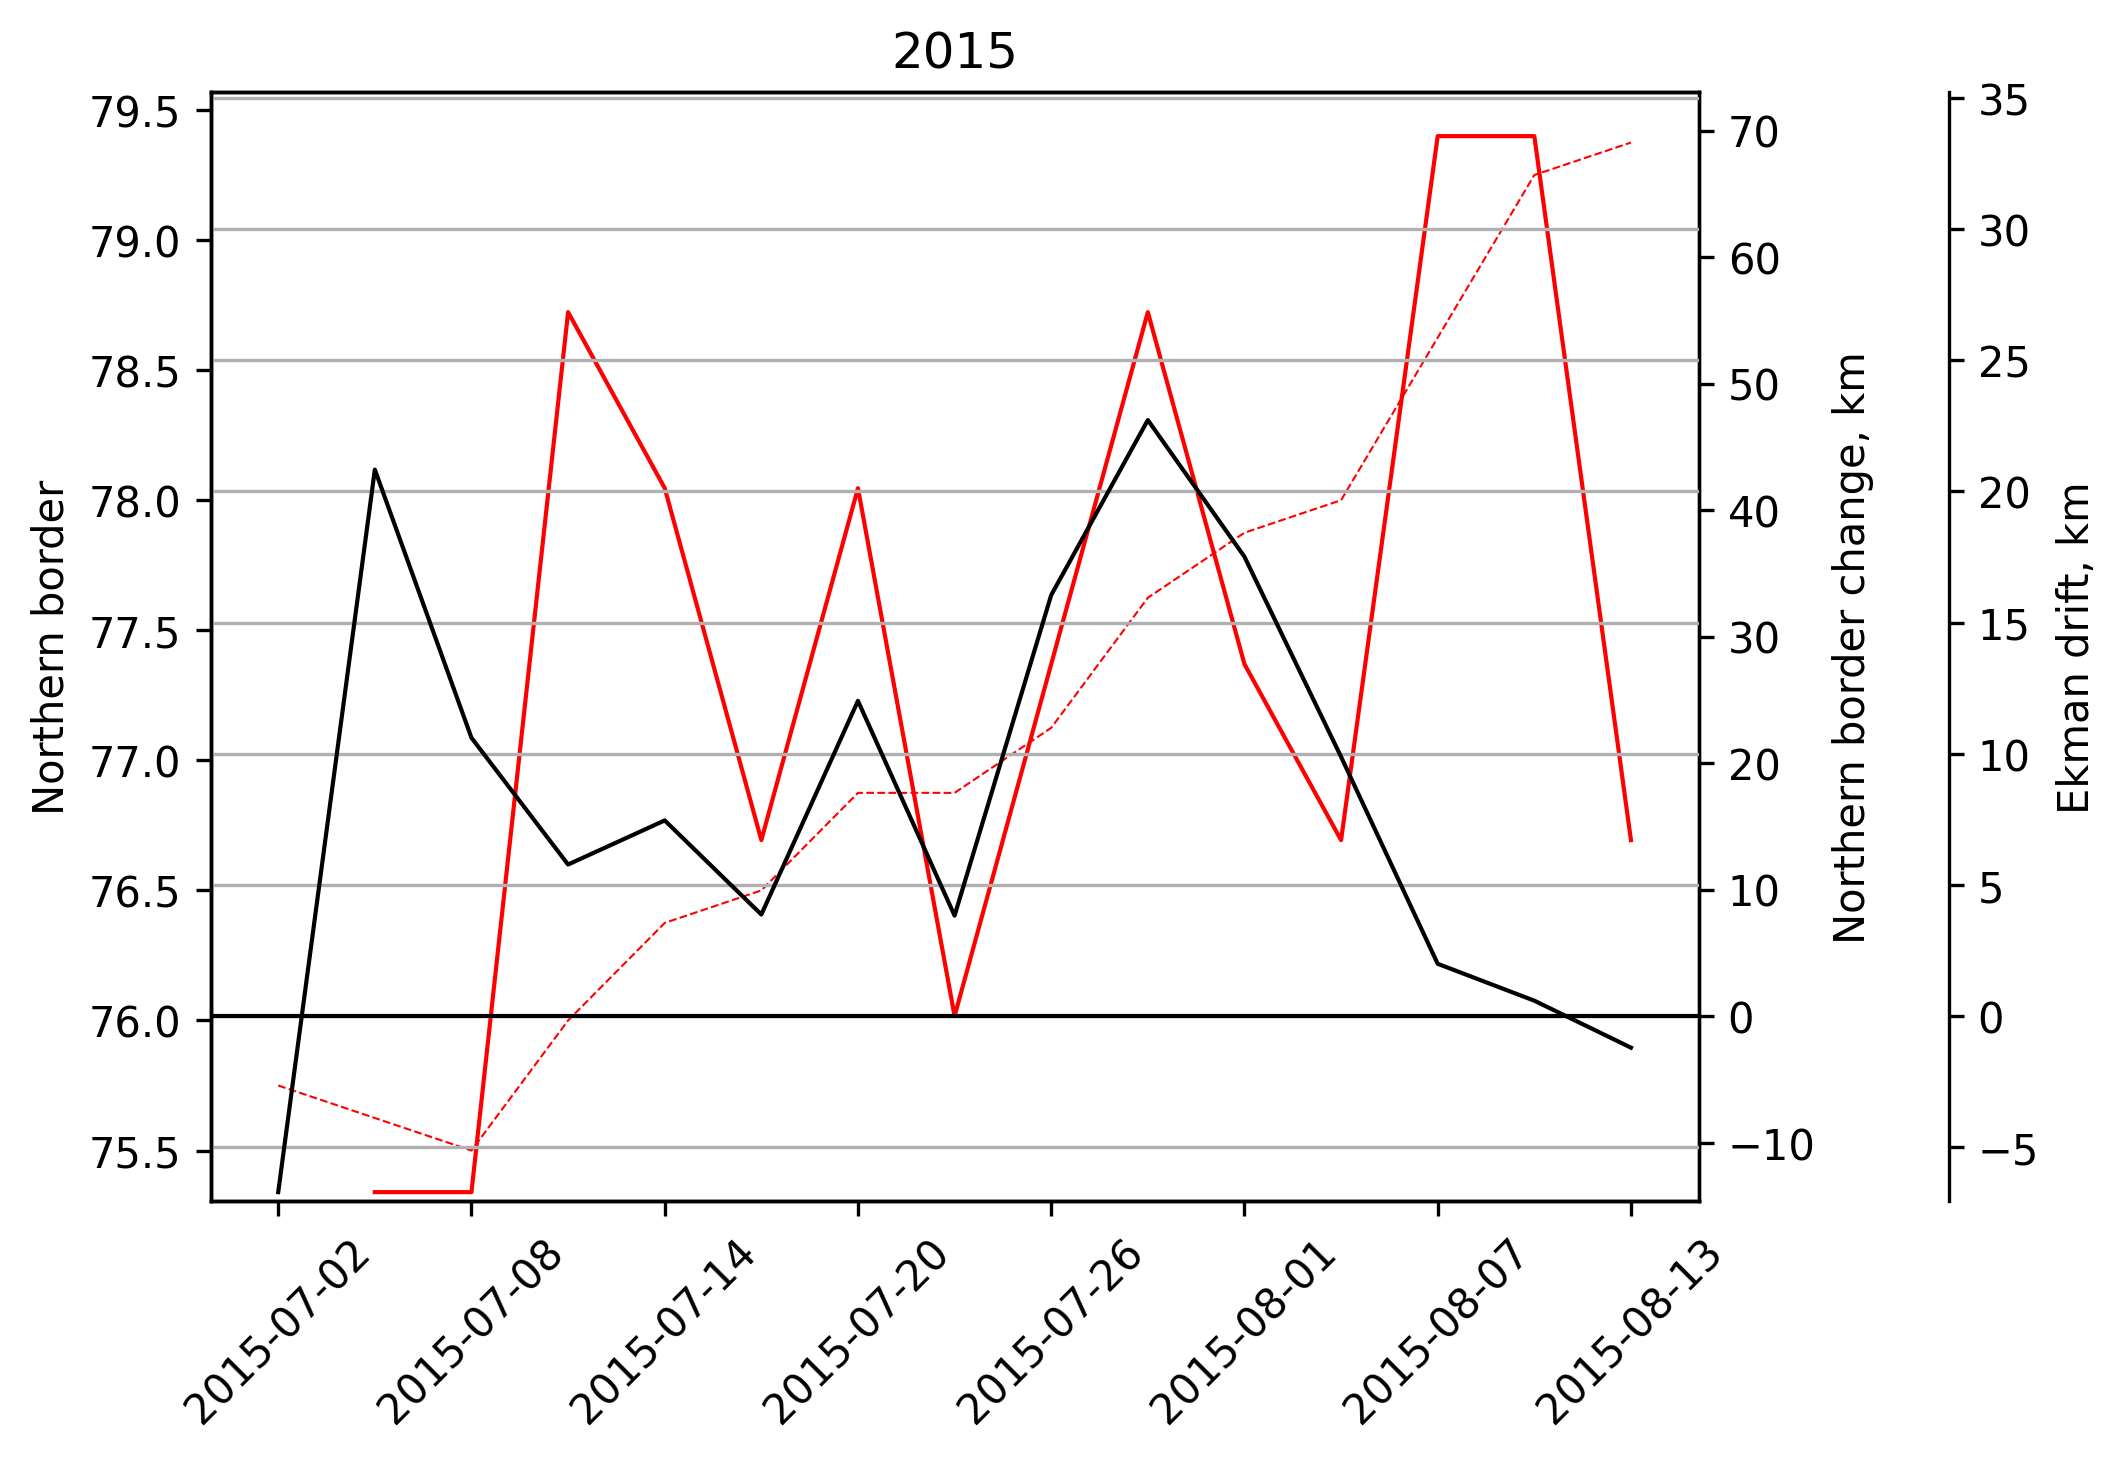

In [18]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [19]:
# 2016
year = 2016
start_date = datetime.datetime(year, 7, 11).date()
finish_date = datetime.datetime(year, 9, 30).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [75.25, 75.75, 75.75, 75.75, 75.125, 75.125, 75.125, 75, 75, 74.625, 74.625, 74.375, 74.125, 74, 74.375,
          np.nan, np.nan, np.nan, np.nan, 73.875, 74.25, 74.25, 74.25, 74.5, 74.5, 74.25, 74.375, 74.375]
NB_80E = [75.875, 76.125, 75.875, 75.875, 75.375, 75.375, 75.375, 75.5, 75.375, 74.875, 74.875, 74.625, 74.875, 74.875,
          74.625, np.nan, np.nan, np.nan, np.nan, 74.5, 74.75, 74.875, 74.75, 74.875, 74.75, 74.75, 75, 74.875]
NB_delta_75E = [np.nan, 0.500, 0.000, 0.000, -0.625, 0.000, 0.000, -0.125, 0.000, -0.375, 0.000, -0.250, -0.250, -0.125,
                0.375, np.nan, np.nan, np.nan, np.nan, np.nan, 0.375, 0.000, 0.000, 0.250, 0.000, -0.250, 0.125, 0.000]
NB_delta_80E = [np.nan, 0.25, -0.25, 0, -0.5, 0, 0, 0.125, -0.125, -0.5, 0, -0.25, 0.25, 0, -0.25, np.nan, np.nan,
                np.nan, np.nan, np.nan, 0.25, 0.125, -0.125, 0.125, -0.125, 0, 0.25, -0.125]

In [20]:
border_north = 76
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [7,8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(123, 53, 241) (123, 53, 241) (123, 13, 61) (123, 13, 61) 123
(84, 53, 241) (84, 53, 241) (84, 13, 61) (84, 13, 61) 84


In [21]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.402260059983328 0.5629440561050661


In [22]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.4665190080874196 [0.35459037 0.32582891] 3.290657684480233
0.56826807782083 [0.47740788 0.09255929] 3.873831180746439


In [23]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

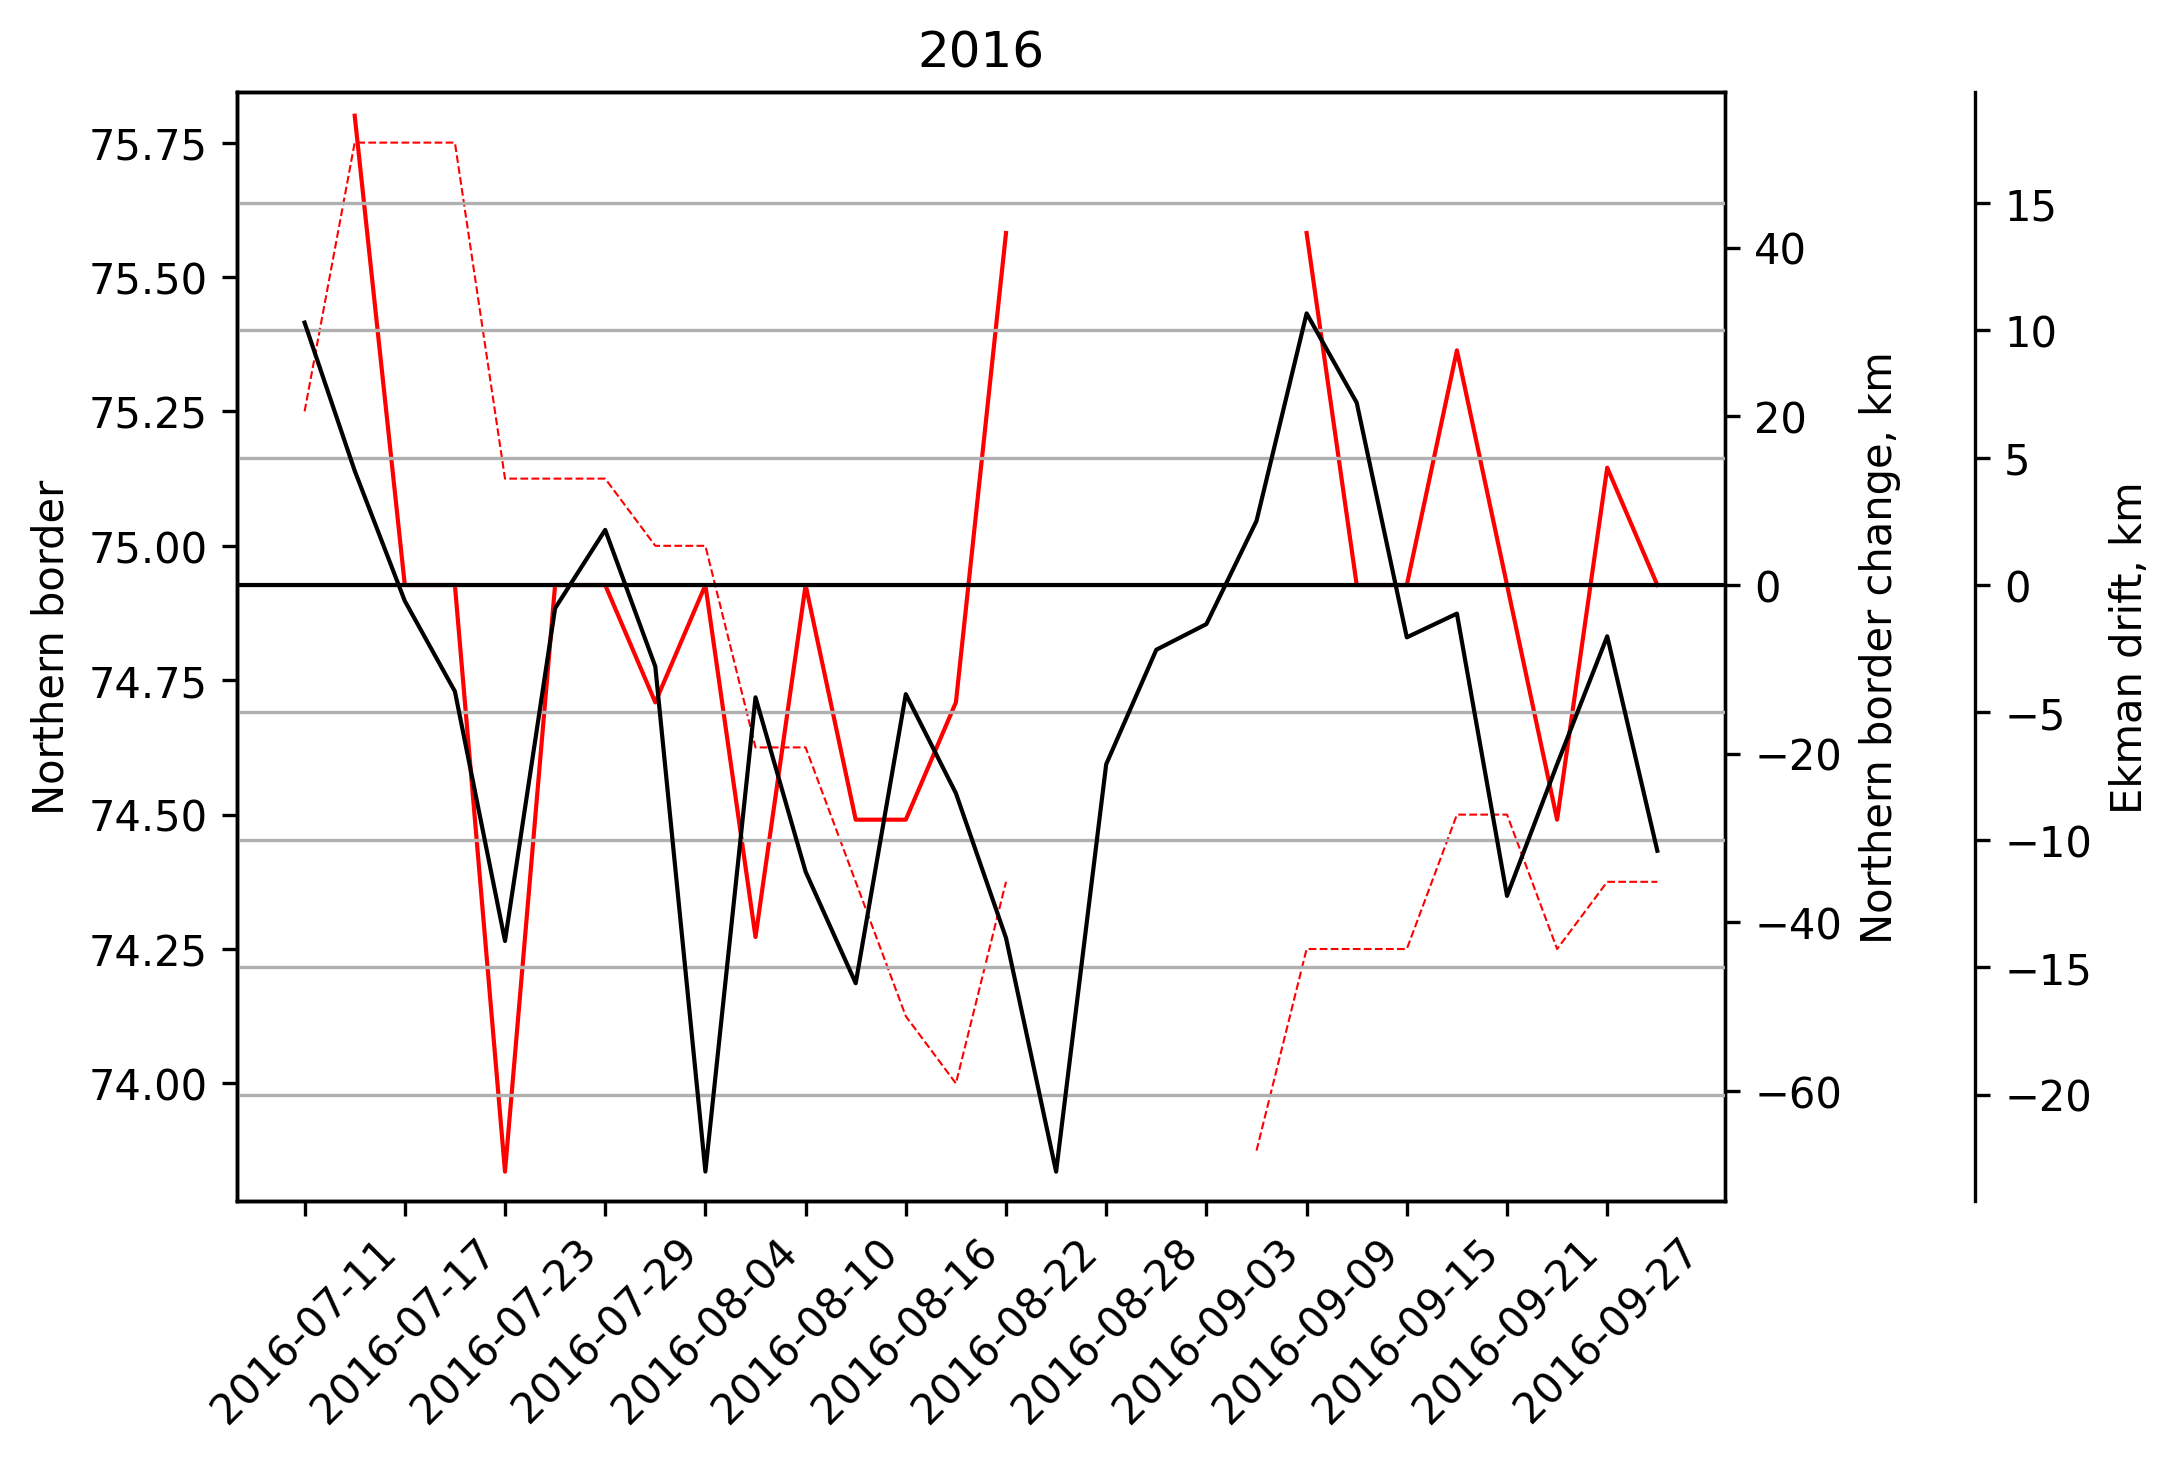

In [24]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [25]:
# 2017
year = 2017
start_date = datetime.datetime(year, 6, 23).date()
finish_date = datetime.datetime(year, 10, 12).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [74.125, 74.25, 74.25, 74.25, 74.25, 74.375, 74.375, 74.375, 74.625, 74.875, 74.75, 74.5, 74.5, 73.875, np.nan, 74.375, 74.75, 74.75, 74.75, 74.75,
          74.625, 74.625, 74.625, 74.875, 75.25, 75.25, 75.375, 75.625, 75.875, 75.875, 75.625, 75.375, 75.375, 75.375, 75.375, 75.25, 75.375, 75.125]
NB_80E = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 75.375, 75.625, 75.375,
          75.25, 75.125, 74.375, 74.375, 75, 75.375, 75.375, 75.625, 75.75, 75.875, 76.125, 75.75, 75.375, 75.375, 75.375, 75.25, 75.125, 75.125, 74.625]
NB_delta_75E = [np.nan, 0.125, 0, 0, 0, 0.125, 0, 0, 0.25, 0.25, -0.125, -0.25, 0, -0.625, np.nan, np.nan, 0.375, 0, 0, 0, -0.125, 0, 0, 0.25, 0.375, 0, 0.125, 0.25, 
                0.25, 0, -0.25, -0.25, 0, 0, 0, -0.125, 0.125, -0.25]
NB_delta_80E = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan,  0.25, -0.25, -0.125,
                -0.125, -0.75, 0, 0.625, 0.375, 0, 0.25, 0.125, 0.125, 0.25, -0.375, -0.375, 0, 0, -0.125, -0.125, 0, -0.5]

In [26]:
border_north = 76
border_south = 73
border_east = 83
border_west = 68
borders = [border_north, border_south, border_east, border_west]

months = [6,7,8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(153, 53, 241) (153, 53, 241) (153, 13, 61) (153, 13, 61) 153
(114, 53, 241) (114, 53, 241) (114, 13, 61) (114, 13, 61) 114


In [27]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.5900810368125509 0.5234684069434942


In [28]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.6047244726921178 [0.48360163 0.10386141] 4.385822656199083
0.5294013555396607 [0.54374577 0.09621165] -1.3867587363266916


In [29]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

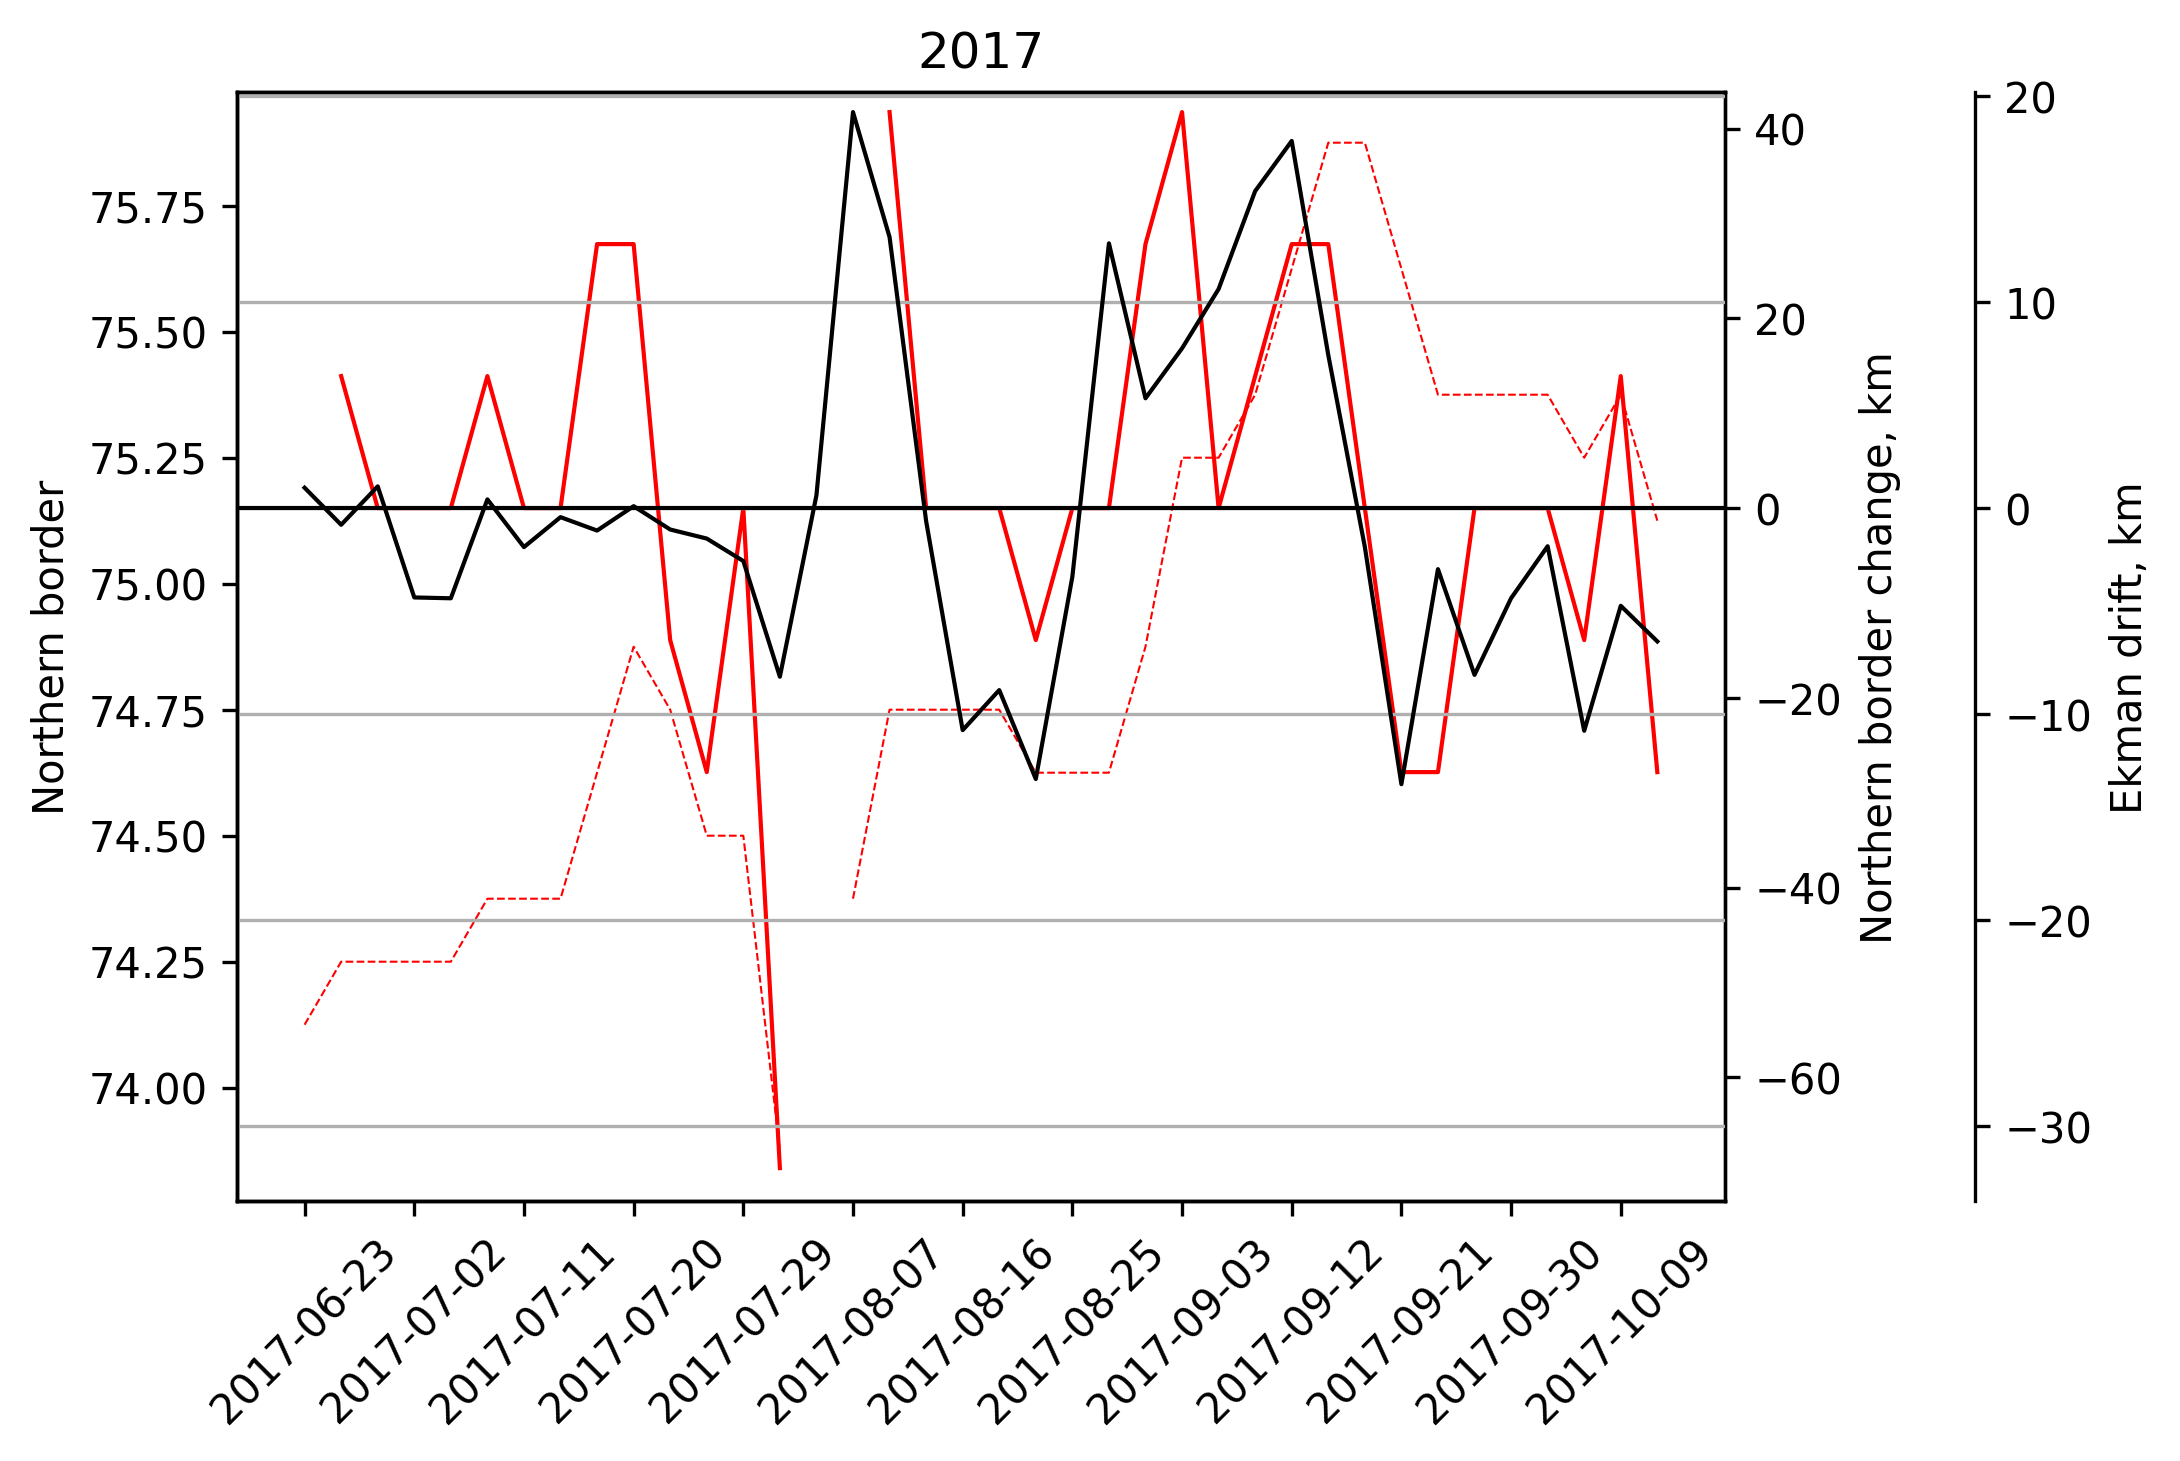

In [30]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [31]:
# 2018
year = 2018
start_date = datetime.datetime(year, 8, 4).date()
finish_date = datetime.datetime(year, 9, 30).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [74.875, 74.875, 75.125, 75.25, 75.25, 75.375, 75.375, 75.25, 75.5, 74.75, 74.625, 74.25, 74.375, 74.375, 74.375,
          74.75, 74.75, 74.875, 75, 75.25]
NB_80E = [74.875, 74.625, 75.125, 75.25, 75.25, 75.375, 75.25, 75.25, 75.125, 74.25, 74.25, np.nan, 74.375, 74.625, 74.75,
          74.75, 75, 75, 74.75, 74.875]
NB_delta_75E = [np.nan, 0, 0.25, 0.125, 0, 0.125, 0, -0.125, 0.25, -0.75, -0.125, -0.375, 0.125, 0, 0, 0.375, 0, 0.125, 0.125, 0.25]
NB_delta_80E = [np.nan, -0.25, 0.5, 0.125, 0, 0.125, -0.125, 0, -0.125, -0.875, 0, np.nan, np.nan, 0.25, 0.125, 0, 0.25, 0, -0.25, 0.125]

In [32]:
border_north = 76
border_south = 73
border_east = 85
border_west = 68
borders = [border_north, border_south, border_east, border_west]

months = [8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(92, 53, 241) (92, 53, 241) (92, 13, 69) (92, 13, 69) 92
(60, 53, 241) (60, 53, 241) (60, 13, 69) (60, 13, 69) 60


In [33]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.7710945757605757 0.5656957679033543


In [34]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.779228133269082 [ 0.76405357 -0.15242409] 8.927073761556628
0.6190729371010281 [ 0.76149604 -0.40972331] 7.94672389917695


In [35]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

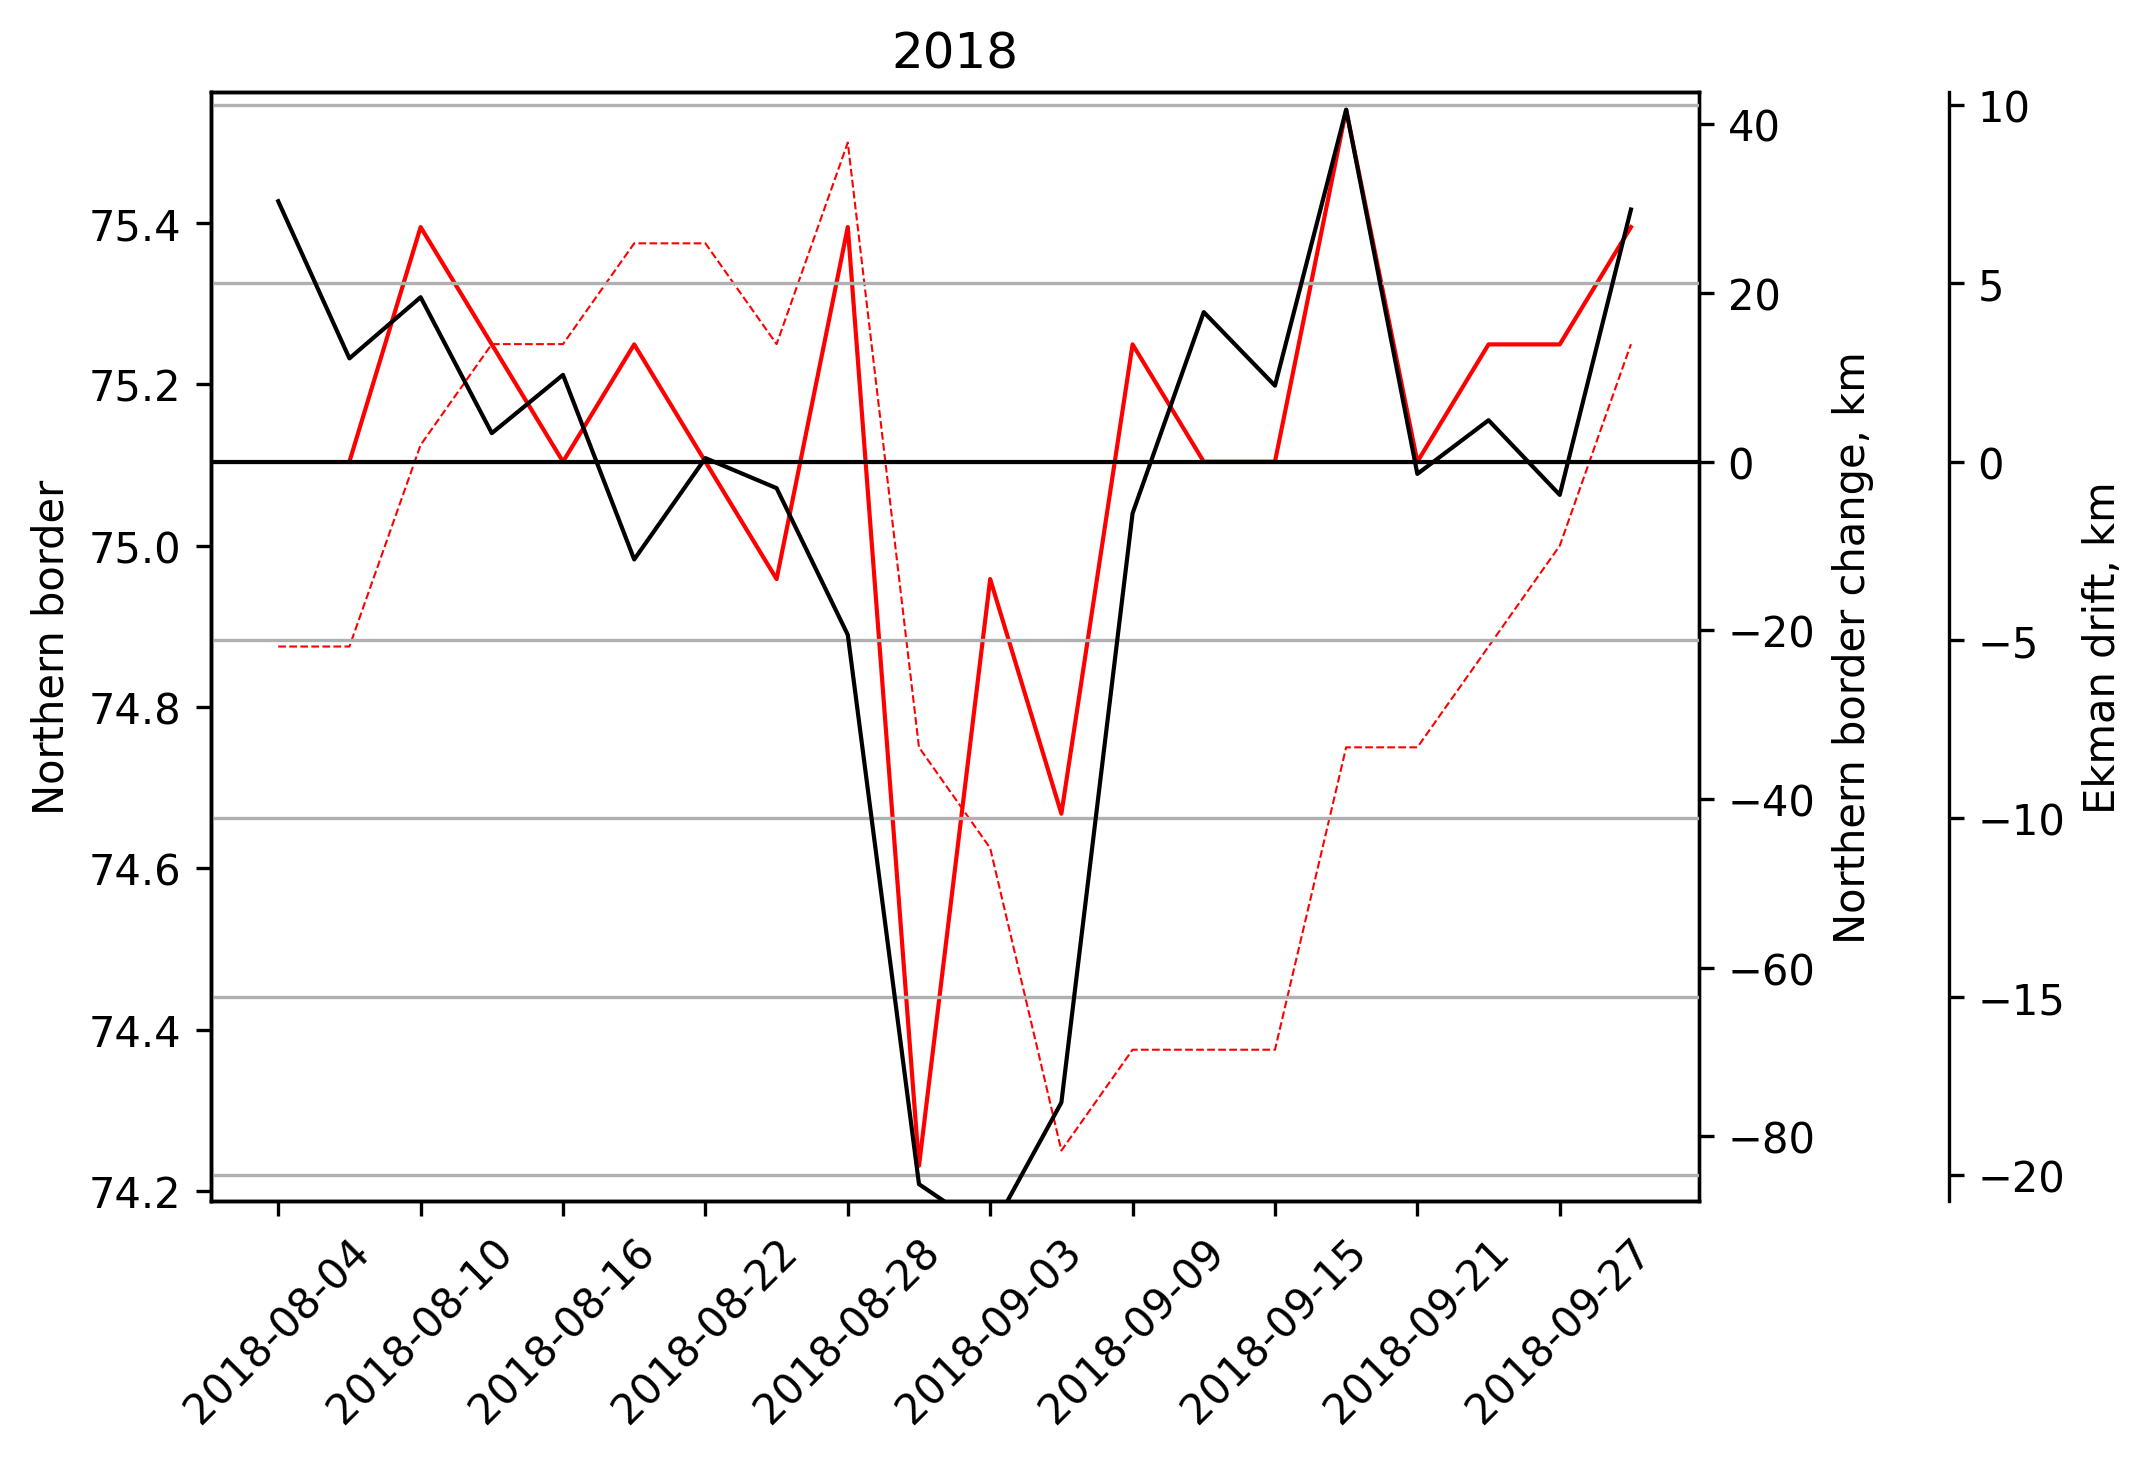

In [36]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [37]:
# 2019
year = 2019
start_date = datetime.datetime(year, 7, 23).date()
finish_date = datetime.datetime(year, 10, 3).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [75.75, 75.875, 76, 76.125, 76.375, 76.625, 76.75, 76.875, 77.125, 77.25, 77.125, 77.125, 77.375, 77.5, 77.25, 77.125, 76.875,
          76.625, 77.125, 77.25, 77.5, 77.625, 77.75, 78.125, 77.875]
NB_80E = [76.25, 76.125, 76.125, 76.75, 76.625, 76.75, 77, 77, 77.25, 77.25, 77.375, 77.375, 77.25, 77.5, 77.875, 77.75, 77.375, 76.75,
          77.125, 77.375, 77.5, 77.5, 77.75, 78.125, 78]
NB_delta_75E = [np.nan, 0.125, 0.125, 0.125, 0.25, 0.25, 0.125, 0.125, 0.25, 0.125, -0.125, 0, 0.25, 0.125, -0.25, -0.125, -0.25, -0.25,
                0.5, 0.125, 0.25, 0.125, 0.125, 0.375, -0.25]
NB_delta_80E = [np.nan, -0.125, 0, 0.625, -0.125, 0.125, 0.25, 0, 0.25, 0, 0.125, 0, -0.125, 0.25, 0.375, -0.125, -0.375, -0.625, 0.375,
                0.25, 0.125, 0, 0.25, 0.375, -0.125]

In [38]:
border_north = 78
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [7,8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(123, 53, 241) (123, 53, 241) (123, 21, 61) (123, 21, 61) 123
(75, 53, 241) (75, 53, 241) (75, 21, 61) (75, 21, 61) 75


In [39]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.3031907208293649 0.11901798816255844


In [40]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.30842925830276985 [0.20085974 0.05876657] 6.767383356997074
0.3964049044737068 [0.07929532 0.51725421] 10.805827181473752


In [41]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

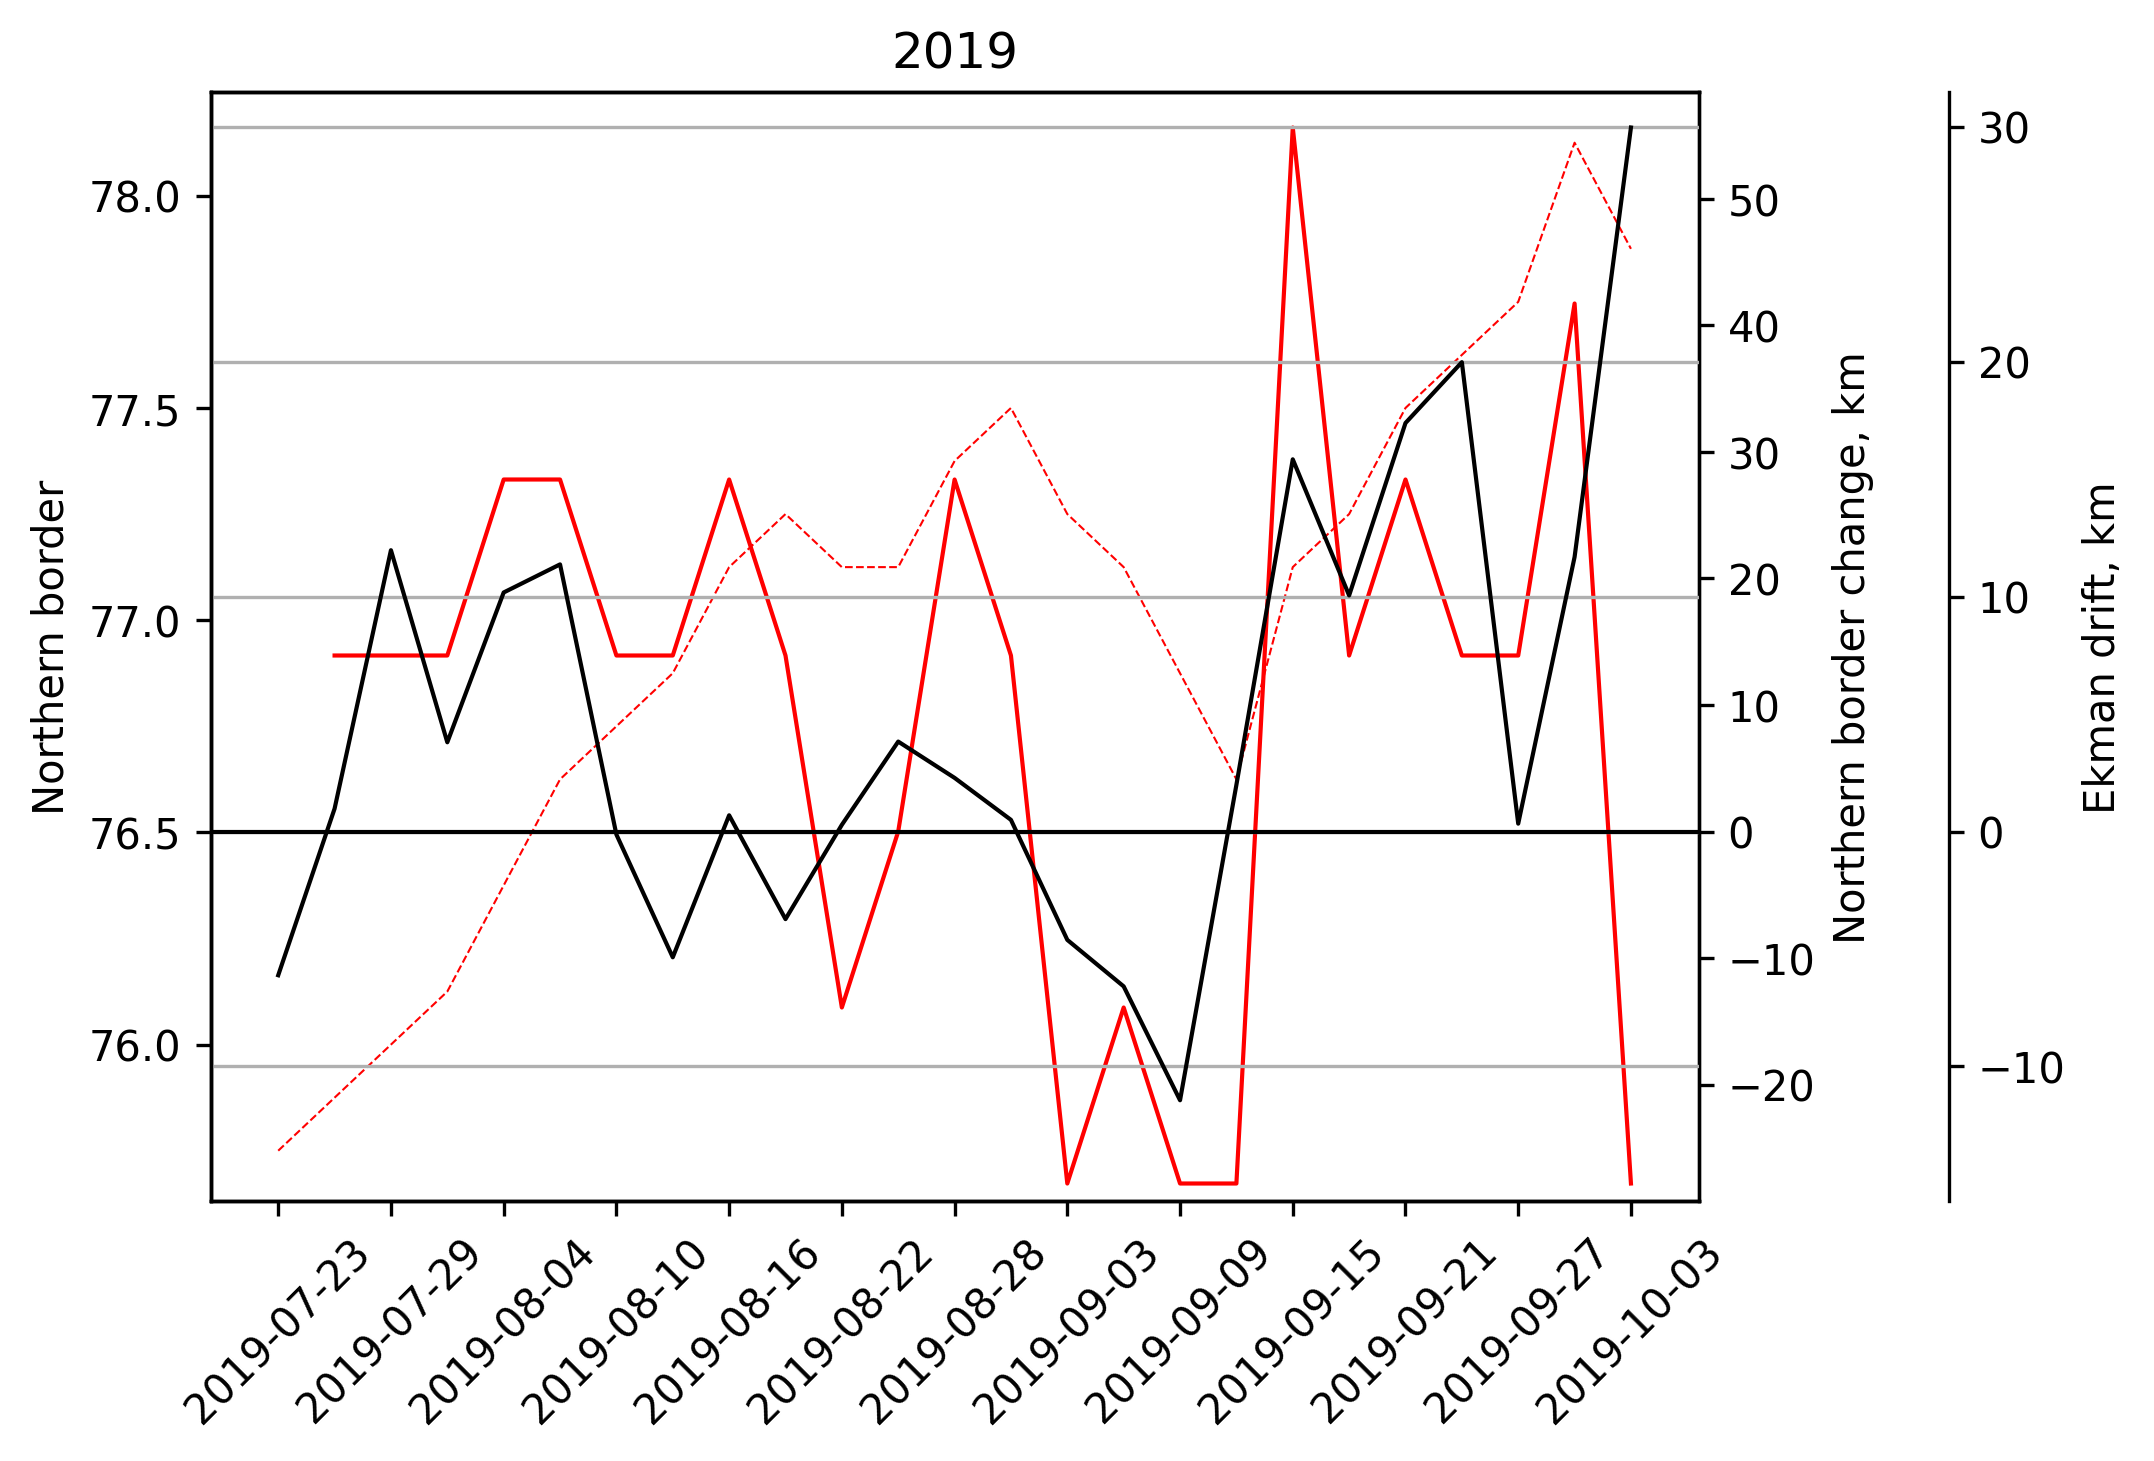

In [42]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [43]:
# 2020
year = 2020
start_date = datetime.datetime(year, 7, 8).date()
finish_date = datetime.datetime(year, 10, 21).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [75.375, 75.875, 75.875, 75.875, 75.625, 75.25, 75.375, 75.625, 76, 75.75, 75.375, 75.625, 75.875, 76.125, 76.125, 76.125, 76.25,
          76.125, 76.125, 76.125, 75.875, 75.75, 75.875, 76.125, 76.375, 76, 76.125, 75.5, 74.875, 75.125, 75.125, 75, 75, 75, 75.375, 75.5]
NB_80E = [76.5, 77.125, 77.375, 77.5, 77.375, 77, 77, 77.125, 77.375, 77.25, 76.625, 77, 77.375, 77, 77, 77.25, 77.25, 77.5, 77.5, 77.375,
          76.875, 76.625, 76.375, 76.5, 76.5, 76.5, 76.25, 75.75, 75.75, 75.375, 75.375, 75.375, 75.5, 75.75, 76, 76.125]
NB_delta_75E = [np.nan, 0.5, 0, 0, -0.25, -0.375, 0.125, 0.25, 0.375, -0.25, -0.375, 0.25, 0.25, 0.25, 0, 0, 0.125, -0.125, 0, 0, -0.25, -0.125,
                0.125, 0.25, 0.25, -0.375, 0.125, -0.625, -0.625, 0.25, 0, -0.125, 0, 0, 0.375, 0.125]
NB_delta_80E = [np.nan, 0.625, 0.25, 0.125, -0.125, -0.375, 0, 0.125, 0.25, -0.125, -0.625, 0.375, 0.375, -0.375, 0, 0.25, 0, 0.25, 0, -0.125, -0.5,
                -0.25, -0.25, 0.125, 0, 0, -0.25, -0.5, 0, -0.375, 0, 0, 0.125, 0.25, 0.25, 0.125]

In [44]:
border_north = 78
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [7,8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(123, 53, 241) (123, 53, 241) (123, 21, 61) (123, 21, 61) 123
(108, 53, 241) (108, 53, 241) (108, 21, 61) (108, 21, 61) 108


In [45]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.5691624693096364 0.6190651908998422


In [46]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.5712587212777155 [ 0.54689536 -0.03755114] -1.4318974497611623
0.6208523506450935 [ 0.61678748 -0.03746784] -3.220426926973058


In [47]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

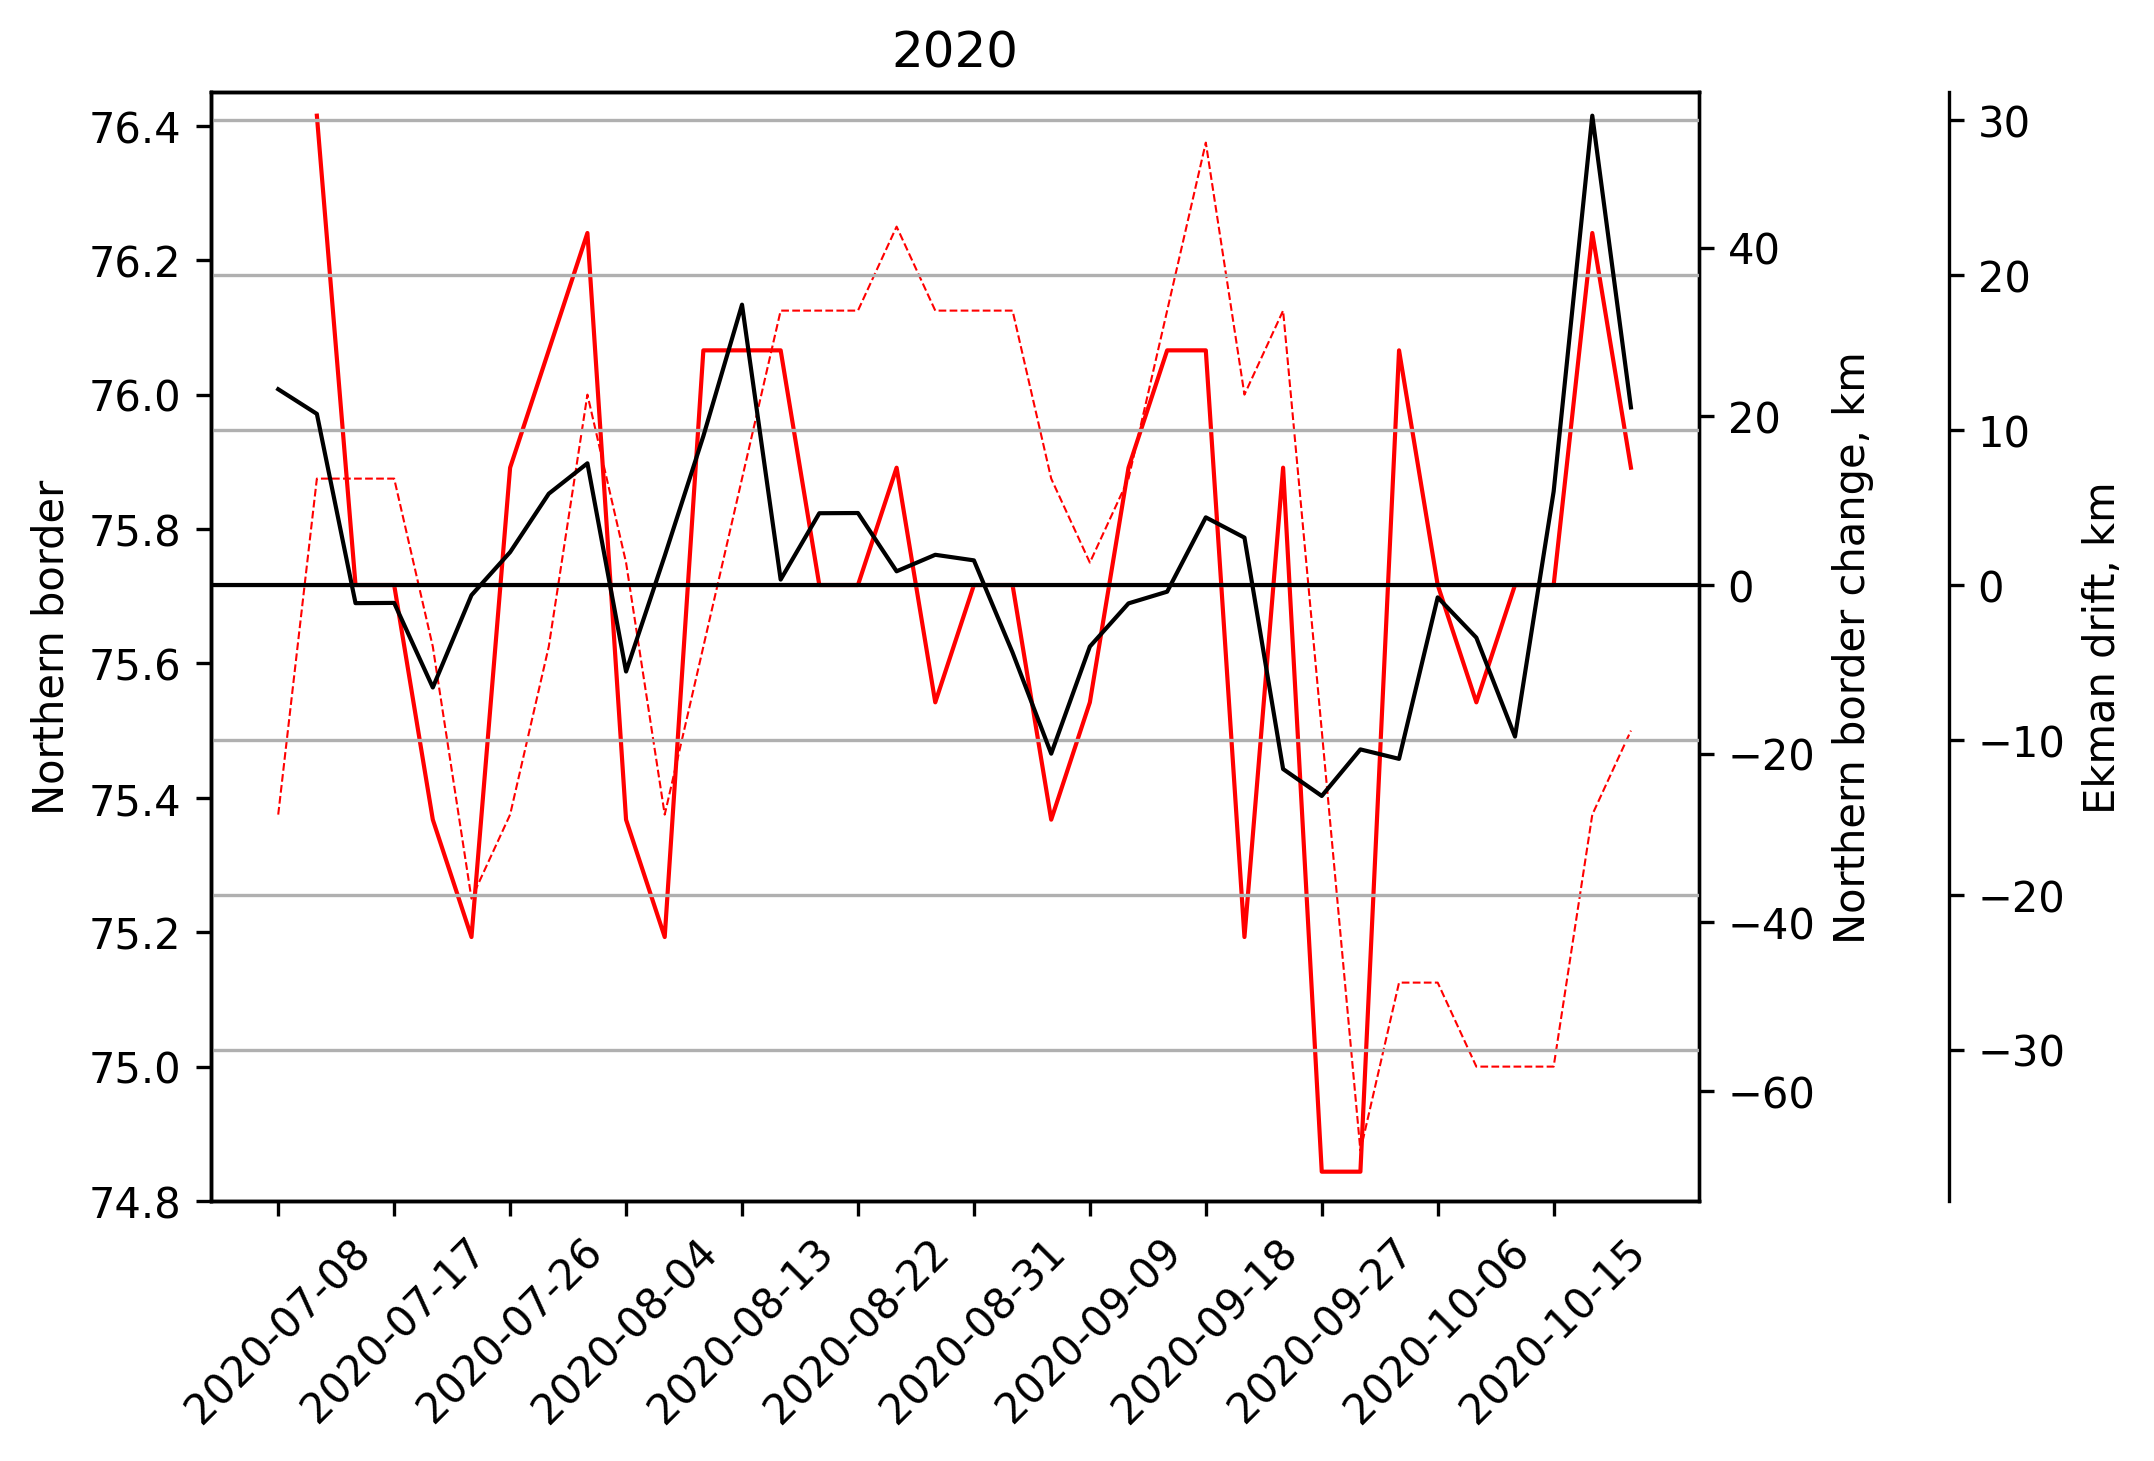

In [48]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [49]:
# 2021
year = 2021
start_date = datetime.datetime(year, 7, 26).date()
finish_date = datetime.datetime(year, 10, 18).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [74.75, 74.75, 75, 75.25, 75.25, 75.25, 75.125, 75.375, 75, 75.125, 75.25, 75.5, 75.75, 75.875, 75.375, 75.625, 75.75,
          75.875, 76.25, 76.125, 76.125, 76, 75.875, 75.75, 75.875, 75.875, 75.75, 75.875, 75.875]
NB_80E = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 76.625, 76.5, 76.5, 75.625, 75.875, 76.375, 76.5, 75.875, 75.875,
          76, 76.375, 76.75, 76.875, 77, 76.625, 76.75, 76.75, 76.75, 77, 76.875, 77.375, np.nan]
NB_delta_75E = [np.nan, 0.000, 0.250, 0.250, 0.000, 0.000, -0.125, 0.250, -0.375, 0.125, 0.125, 0.250, 0.250, 0.125, -0.500, 0.250,
                0.125, 0.125, 0.375, -0.125, 0.000, -0.125, -0.125, -0.125, 0.125, 0.000, -0.125, 0.125, 0.000]
NB_delta_80E = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, -0.125, 0, -0.875, 0.25, 0.5, 0.125, -0.625, 0, 0.125, 
                0.375, 0.375, 0.125, 0.125, -0.375, 0.125, 0, 0, 0.25, -0.125, 0.5, np.nan]

In [50]:
border_north = 77
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [7,8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(123, 53, 241) (123, 53, 241) (123, 17, 61) (123, 17, 61) 123
(87, 53, 241) (87, 53, 241) (87, 17, 61) (87, 17, 61) 87


In [51]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.35761794637200695 0.18314314089942585


In [52]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.36443576830453944 [0.392765   0.05441123] 2.9380285894395466
0.2433020227204198 [ 0.14659705 -0.19447868] 1.8486681407010384


In [53]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

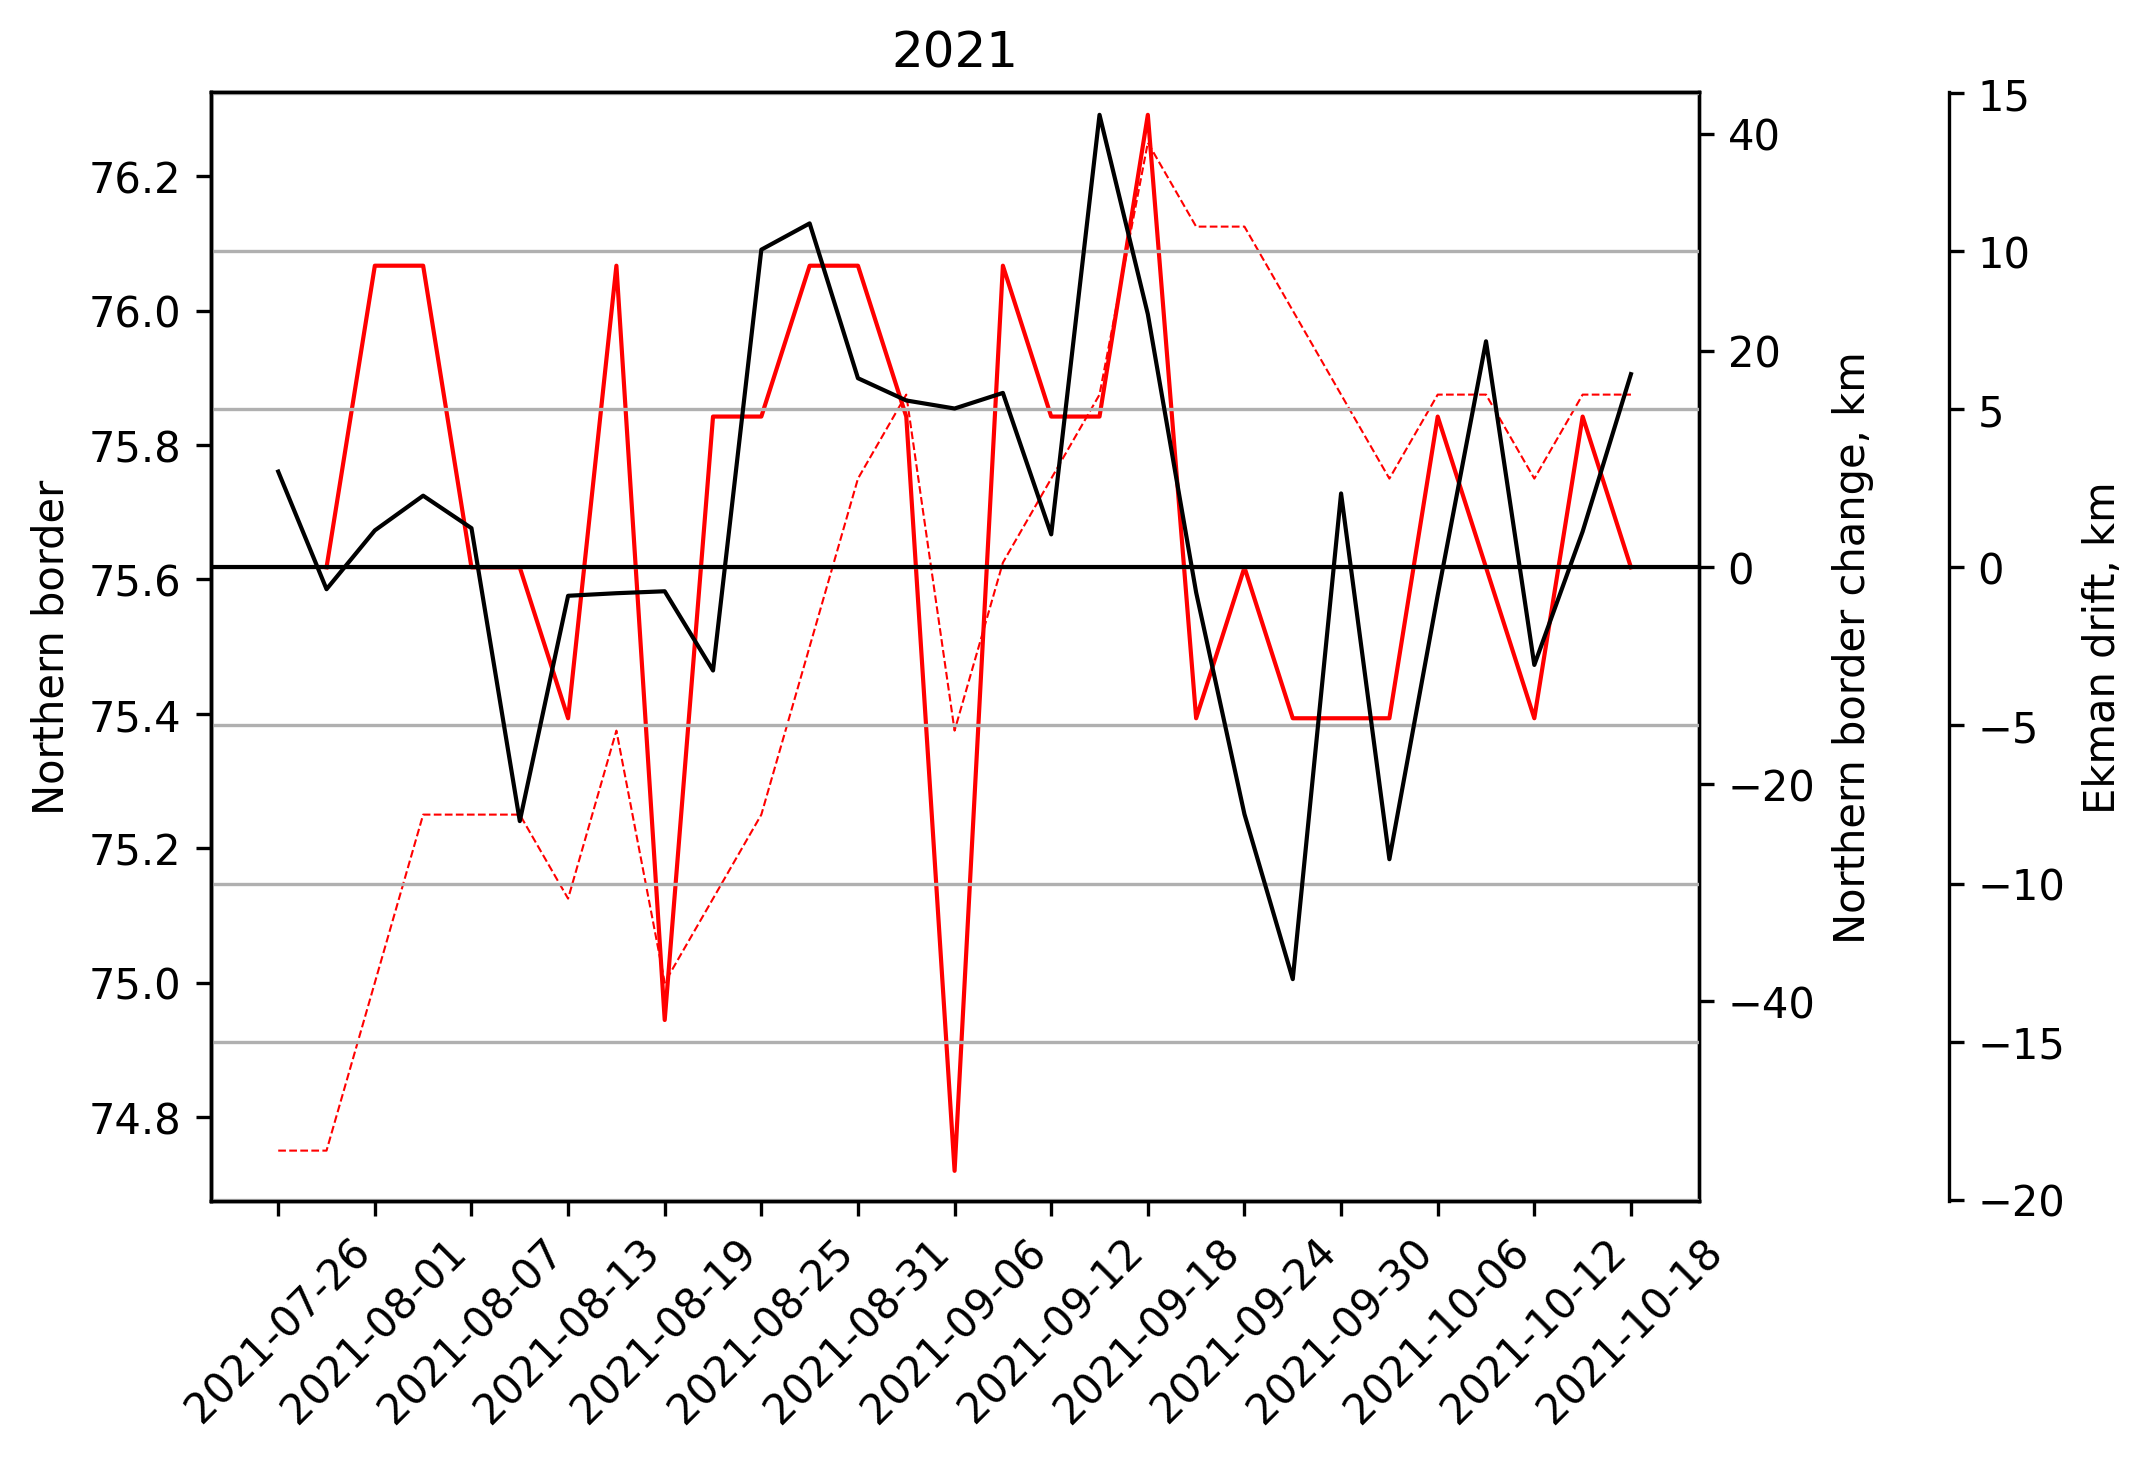

In [54]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [55]:
# 2022
year = 2022
start_date = datetime.datetime(year, 9, 24).date()
finish_date = datetime.datetime(year, 10, 24).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [77.25, 77.25, 76.875, 77, 77, 77.25, 77.25, 77, 77, 77.5, 78]
NB_80E = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
NB_delta_75E = [np.nan, 0.000, -0.375, 0.125, 0.000, 0.250, 0.000, -0.250, 0.000, 0.500, 0.500]
NB_delta_80E = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

In [56]:
border_north = 78
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(61, 53, 241) (61, 53, 241) (61, 21, 61) (61, 21, 61) 61
(33, 53, 241) (33, 53, 241) (33, 21, 61) (33, 21, 61) 33


In [57]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.9123094327410948 nan


In [58]:
# df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
# print(df75['a'].corr(df75['b']), coef75, intercept75)
# print(df80['a'].corr(df80['b']), coef80, intercept80)

In [59]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

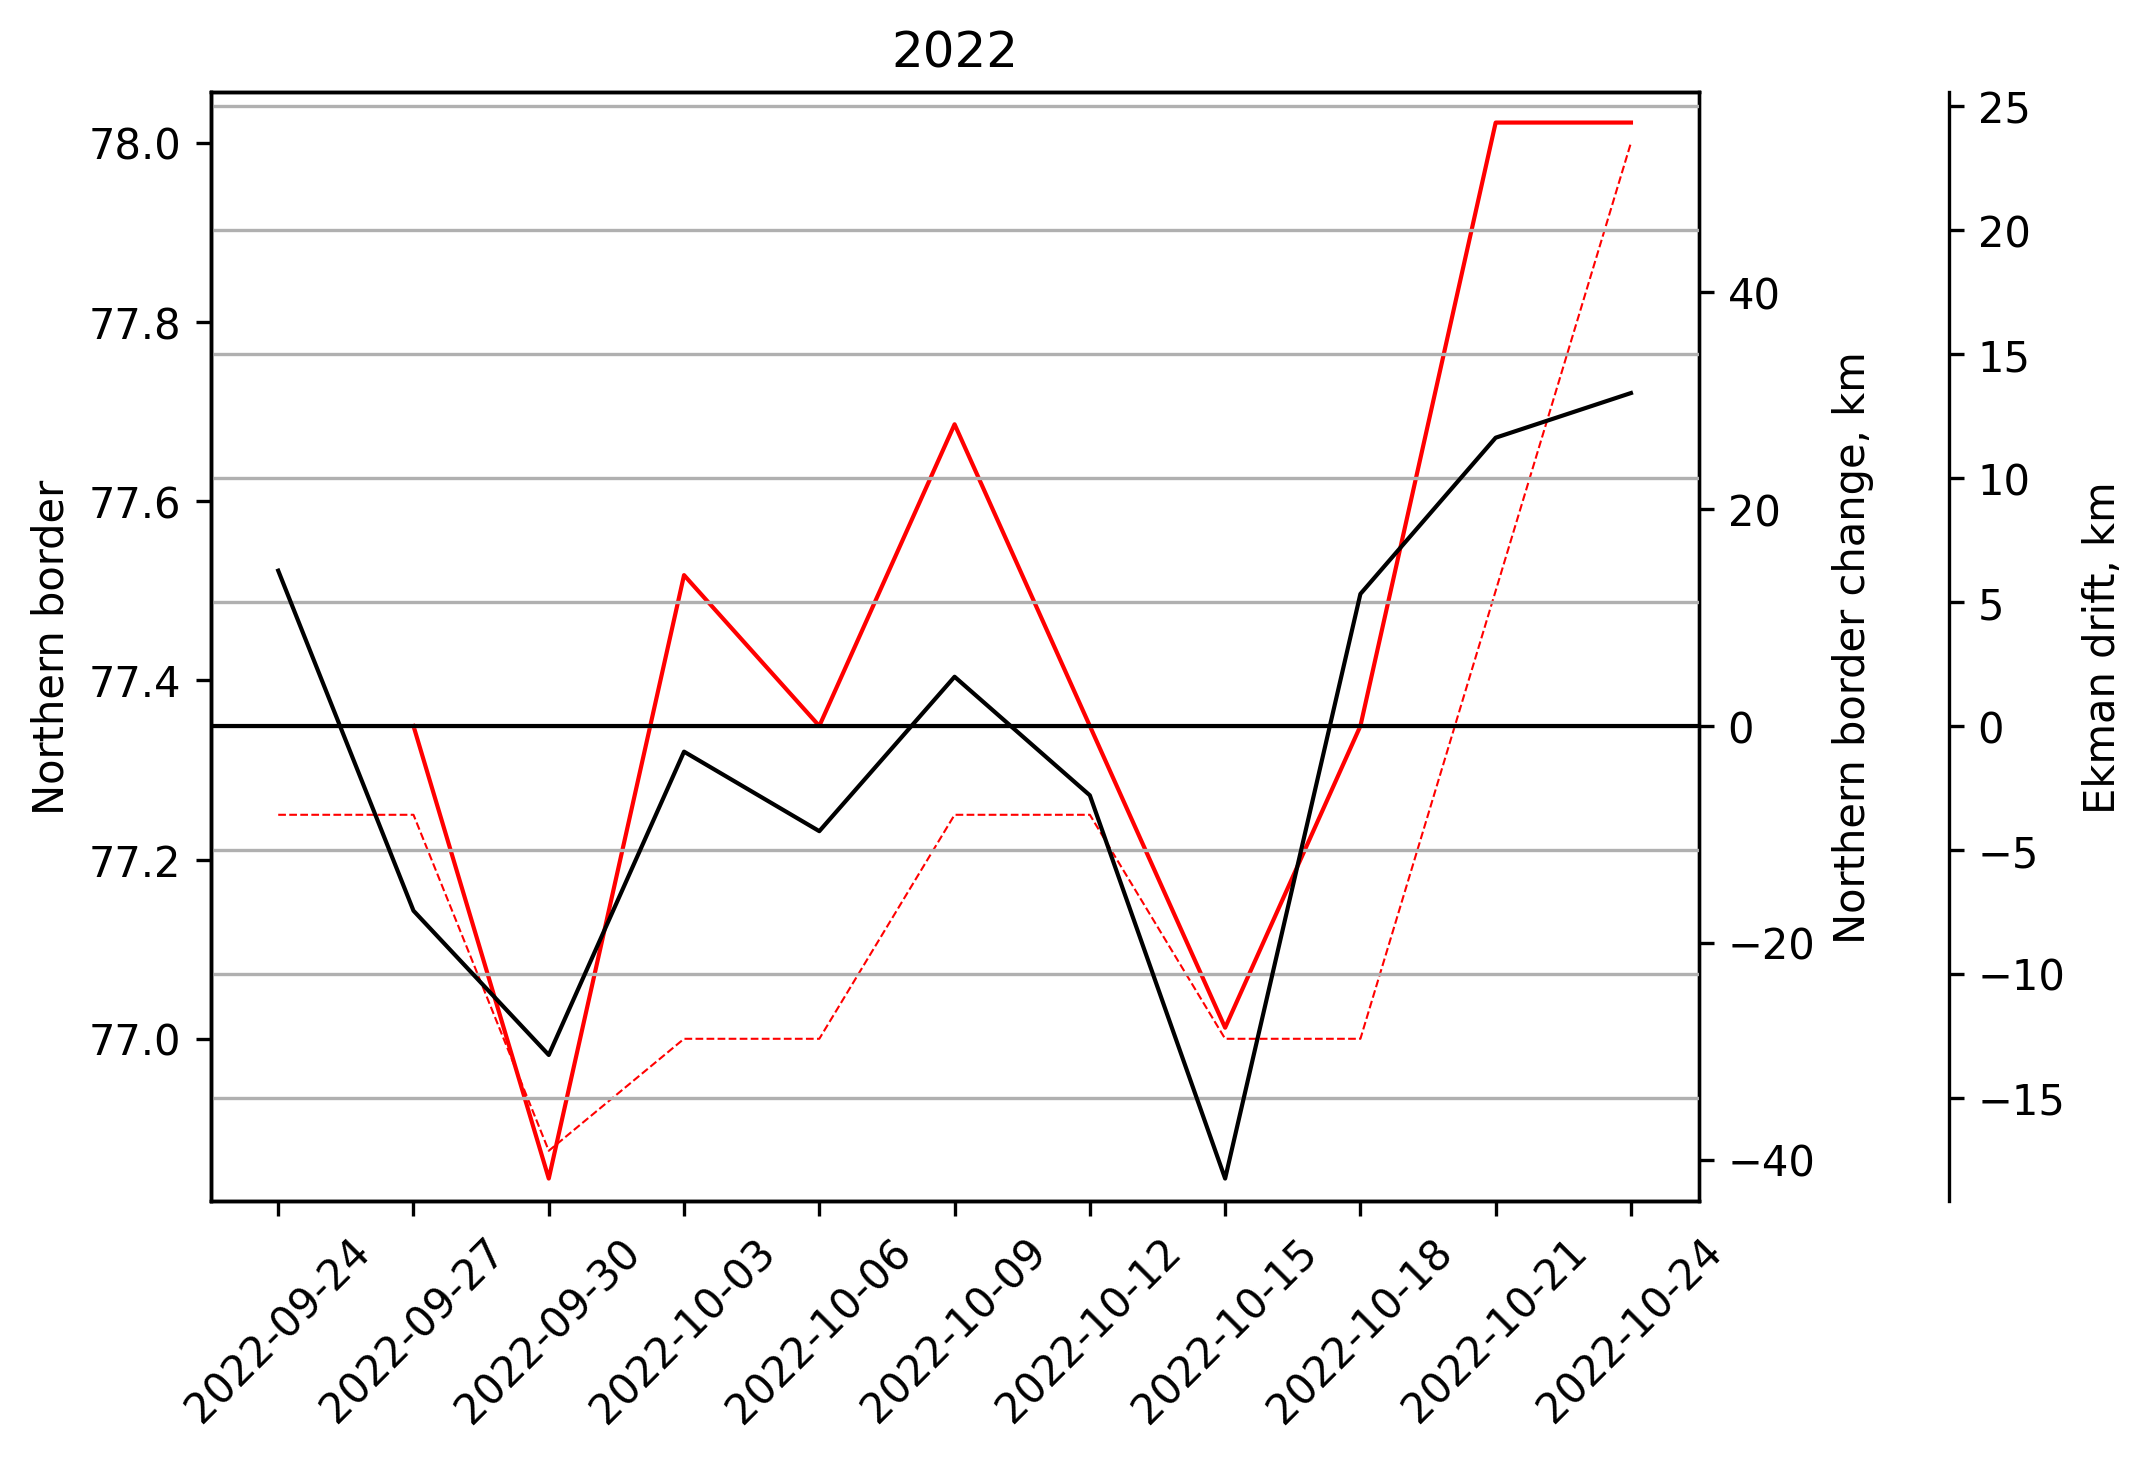

In [60]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [61]:
# 2023
year = 2023
start_date = datetime.datetime(year, 7, 20).date()
finish_date = datetime.datetime(year, 10, 6).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [76, 75.875, 76, 76.25, 76.125, 76.25, 76.5, 76.25, 76.125, 76.25, 76.375, 76.875, 77.125, 77.25, 77.125,
          77, 76.875, 76.75, 76.375, 76.375, 76.5, 76.625, 77.125, 77.125, 77.375, 77.375, 77.375]
NB_80E = [np.nan, np.nan, np.nan, 75.375, 75.375, 76.25, 76.5, 76.125, 76.125, 76.25, 76.5, 76.75, 76.75, 77, 77,
          76.875, 76.875, 77.125, 76.375, 76.375, 76.625, 76.875, 77.375, 77, 77.5, 77.75, 77.875]
NB_delta_75E = [np.nan, -0.125, 0.125, 0.25, -0.125, 0.125, 0.25, -0.25, -0.125, 0.125, 0.125, 0.5, 0.25,
                0.125, -0.125, -0.125, -0.125, -0.125, -0.375, 0, 0.125, 0.125, 0.5, 0, 0.25, 0, 0]
NB_delta_80E = [np.nan, np.nan, np.nan, np.nan, 0, 0.875, 0.25, -0.375, 0, 0.125, 0.25, 0.25, 0, 0.25, 0,
                -0.125, 0, 0.25, -0.75, 0, 0.25, 0.25, 0.5, -0.375, 0.5, 0.25, 0.125]

In [62]:
border_north = 78
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [7,8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

(123, 53, 241) (123, 53, 241) (123, 21, 61) (123, 21, 61) 123
(81, 53, 241) (81, 53, 241) (81, 21, 61) (81, 21, 61) 81


In [63]:
u10_mean_neg, v10_mean, wind_mean, U_neg, V = mean_wind(array_u10_upd_filtered, array_v10_upd_filtered)
NB_delta_75E_km, NB_delta_80E_km, U_Ekman, U_Ekman_sm, U_Ekman_sum, V_Ekman_sm, V_Ekman_sum, Ekman_data_u, Ekman_data_v = make_ekman(NB_delta_75E, NB_delta_80E, U_neg, V)
U_neg_averages, V_averages, df = wind_3d(U_neg, V, NB_delta_75E_km, NB_delta_80E_km)
print(df['a'].corr(df['b']), df['a'].corr(df['c']))

0.4538625925012925 0.33933627645533726


In [64]:
df75, df80, coef75, intercept75, coef80, intercept80 = make_reg_coef(U_neg_averages, V_averages, NB_delta_75E_km, NB_delta_80E_km)
print(df75['a'].corr(df75['b']), coef75, intercept75)
print(df80['a'].corr(df80['b']), coef80, intercept80)

0.4717761780923083 [ 0.38059869 -0.13206881] 6.39896384348216
0.457096223806575 [0.41005935 0.46635538] 12.331589506371088


In [65]:
all_U_neg.append(U_neg)
all_NB_delta_75E_km.append(NB_delta_75E_km)
all_Ekman_data_u.append(Ekman_data_u)

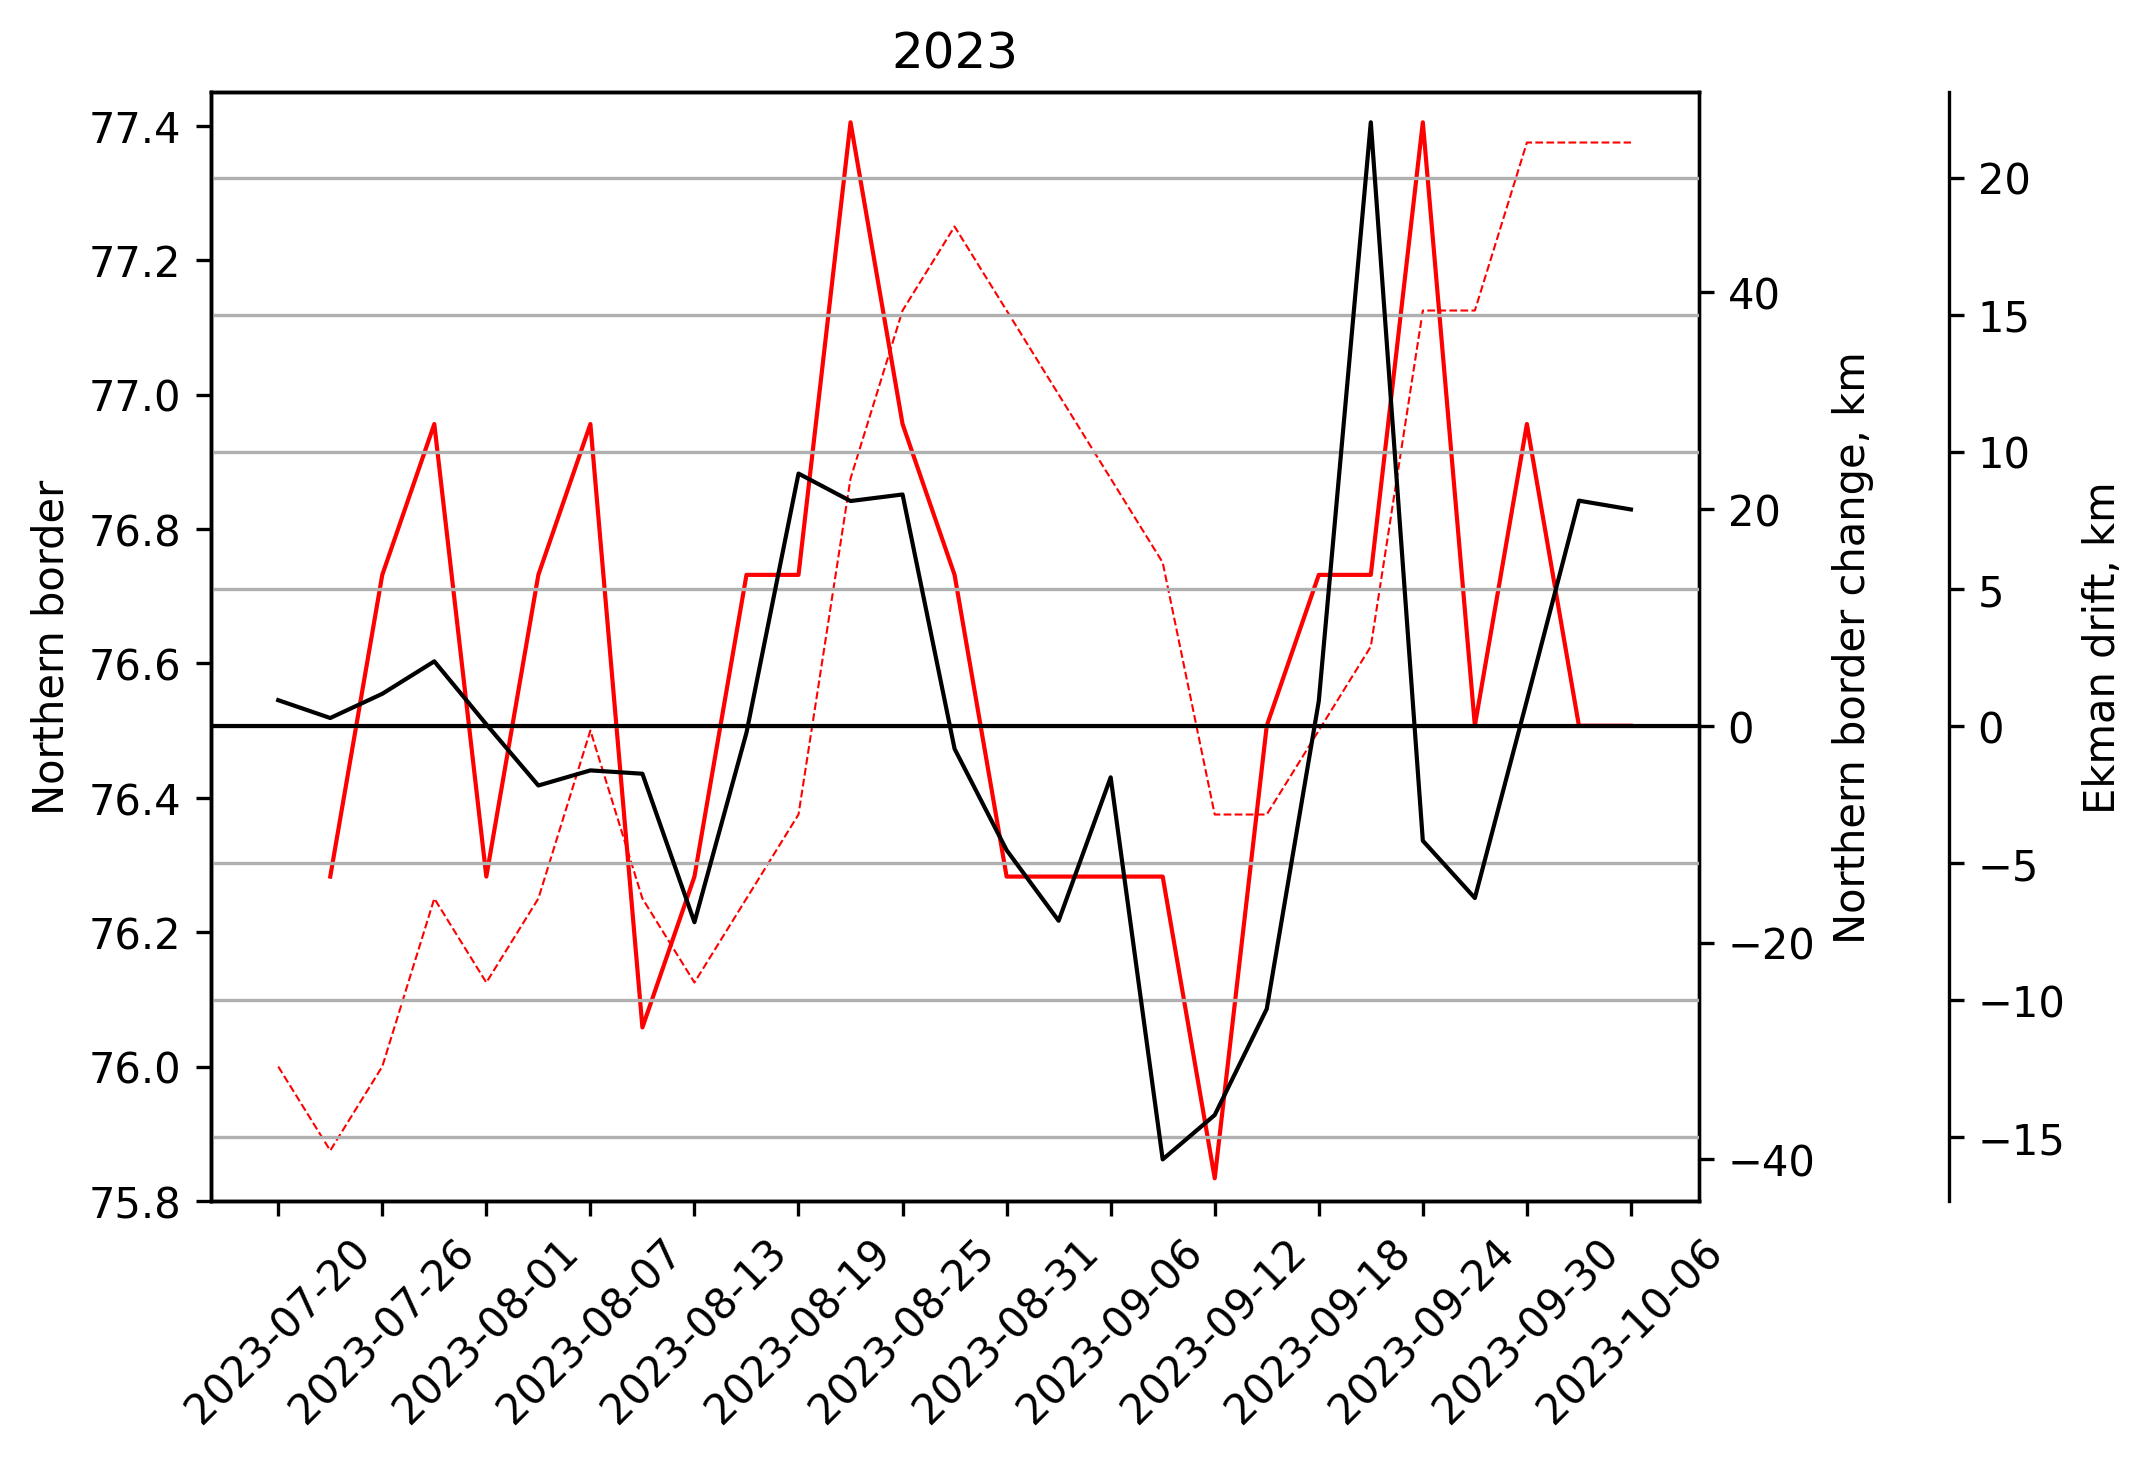

In [66]:
draw_border_wind(dates, NB_75E, NB_delta_75E_km, dates_wind, U_Ekman_sm, Ekman_data_u, str(year))

In [67]:
def flatten(lst):
    for item in lst:
        if isinstance(item, list):
            yield from flatten(item)
        else:
            yield item

In [68]:
all_U_neg_flat = list(flatten(all_U_neg))
all_NB_delta_75E_km_flat = list(flatten(all_NB_delta_75E_km))
all_Ekman_data_u_flat = list(flatten(all_Ekman_data_u))

In [69]:
len(all_U_neg_flat), len(all_NB_delta_75E_km_flat), len(all_Ekman_data_u_flat)

(687, 229, 229)

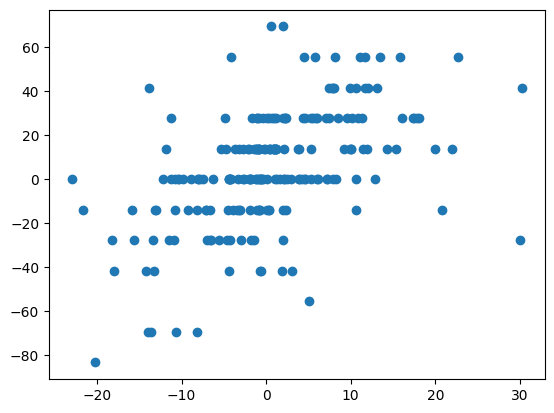

In [70]:
plt.plot(all_Ekman_data_u_flat, all_NB_delta_75E_km_flat, linestyle='None', marker='o')

In [71]:
x = np.array(all_Ekman_data_u_flat)
y = np.array(all_NB_delta_75E_km_flat)

mask = ~np.isnan(x) & ~np.isnan(y)
x2 = x[mask]
y2 = y[mask]

In [72]:
np.corrcoef(x2, y2)[0, 1]

np.float64(0.517222446893562)

In [ ]:
# 2024
year = 2024
start_date = datetime.datetime(year, 8, 1).date()
finish_date = datetime.datetime(year, 10, 9).date()
dates = [(start_date + datetime.timedelta(days=i*3)) for i in range((finish_date - start_date).days // 3 + 1)]
NB_75E = [75.625, 76, 75.75, 75.875, 76, 76.25, 76.5, 76.75, 76.75, 76.5, 76.375, 76.375,
          76.375, 75.625, 75.625, 76, 76, 76.75, 76.875, 77.75, 78.25, 79, 79.375, 79.375]
NB_80E = [76, 76.375, 76, 75.875, 76.125, 76.375, 76.375, 76.625, 76.625, 76.5, 76.375, 76.25,
          76.25, 75.625, 75.375, 75.5, 75.375, 75.375, np.nan, 76.25, 76.25, np.nan, np.nan, np.nan]
NB_delta_75E = [np.nan, 0.375, -0.25, 0.125, 0.125, 0.25, 0.25, 0.25, 0, -0.25, -0.125,
                0, 0, -0.75, 0, 0.375, 0, 0.75, 0.125, 0.875, 0.5, 0.75, 0.375, 0]
NB_delta_80E = [np.nan, 0.375, -0.375, -0.125, 0.25, 0.25, 0, 0.25, 0, -0.125, -0.125, -0.125,
                0, -0.625, -0.25, 0.125, -0.125, 0, np.nan, np.nan, 0, np.nan, np.nan, np.nan]

2024 нет, надо качать ветер

border_north = 78
border_south = 73
border_east = 85
border_west = 70
borders = [border_north, border_south, border_east, border_west]

months = [8,9,10]

dates_wind, array_u10_filtered, array_v10_filtered, array_u10_upd_filtered, array_v10_upd_filtered = make_wind(borders, months, year, start_date, finish_date)

u10_mean_neg = [-np.mean(array_u10_upd_filtered[i]) for i in range(array_u10_upd_filtered.shape[0])]
v10_mean = [np.mean(array_v10_upd_filtered[i]) for i in range(array_v10_upd_filtered.shape[0])]
wind_mean = [(a**2 + b**2)**0.5 for a, b in zip(u10_mean_neg, v10_mean)]
U_neg = [a * b for a, b in zip(wind_mean, u10_mean_neg)]

draw_border_wind(dates, NB_75E, NB_80E, NB_delta_75E, NB_delta_80E, dates_wind, U_neg, str(year))